#Correlación

##El Cuarteto de Anscombe: Por qué NUNCA debe confiar solo en los números

--- ESTADÍSTICAS DESCRIPTIVAS POR GRUPO ---
         Media_X  Media_Y  Var_X  Correlacion
dataset                                      
I            9.0      7.5   11.0         0.82
II           9.0      7.5   11.0         0.82
III          9.0      7.5   11.0         0.82
IV           9.0      7.5   11.0         0.82

Conclusión numérica: ¡Los 4 grupos parecen matemáticamente idénticos!

--- LA REALIDAD VISUAL ---


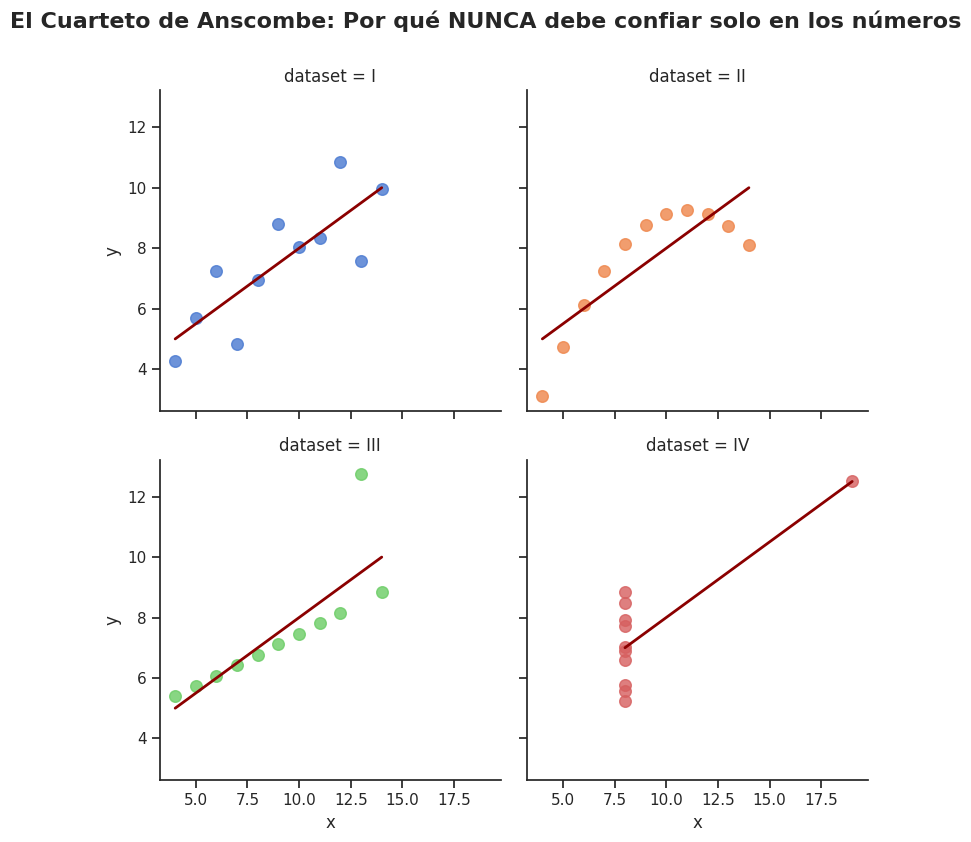

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Cargar el dataset integrado de Anscombe
df_anscombe = sns.load_dataset("anscombe")

# 2. Demostrar el "Engaño Numérico"
print("--- ESTADÍSTICAS DESCRIPTIVAS POR GRUPO ---")
resumen = df_anscombe.groupby("dataset").agg(
    Media_X=("x", "mean"),
    Media_Y=("y", "mean"),
    Var_X=("x", "var"),
    Correlacion=("x", lambda df: df.corr(df_anscombe.loc[df.index, "y"]))
).round(2)
print(resumen)
print("\nConclusión numérica: ¡Los 4 grupos parecen matemáticamente idénticos!")

# 3. Revelar la Realidad Visual
print("\n--- LA REALIDAD VISUAL ---")
sns.set_theme(style="ticks")

# Crear una cuadrícula de gráficos que ajuste una regresión lineal (lmplot)
g = sns.lmplot(
    data=df_anscombe, x="x", y="y", col="dataset", hue="dataset",
    col_wrap=2, ci=None, palette="muted", height=4,
    scatter_kws={"s": 70, "alpha": 0.8},
    line_kws={"linewidth": 2, "color": "darkred"}
)

g.fig.suptitle("El Cuarteto de Anscombe: Por qué NUNCA debe confiar solo en los números", y=1.05, fontsize=16, fontweight='bold')
plt.show()

## La Paradoja de los Datos: Auditoría al Programa de Capacitación

**Contexto del Negocio:**
El Director de Recursos Humanos está furioso. Hace seis meses aprobó un costoso programa de "Capacitación Continua" para los analistas de la compañía. Hoy, al cruzar la variable de `Horas_Capacitacion` contra el `Score_Productividad` de los empleados, calculó un coeficiente de correlación de Pearson de **-0.84**.

Su conclusión fue tajante: *"A mayor cantidad de horas de capacitación, la productividad de los empleados se desploma. El programa es un fracaso, los distrae de su trabajo y será cancelado inmediatamente"*.

**Requerimiento Analítico:**
Como Científico de Datos principal, a usted le parece que cancelar un programa de capacitación basándose en un solo número es apresurado. Usted solicita acceso a la base de datos, la cual incluye una tercera variable que el Director ignoró: el `Nivel_Seniority` del empleado (Junior, Semi-Senior, Senior).

Su misión es auditar el cálculo del Director.
1. Calcule la correlación global para verificar si el Director calculó bien el número.
2. Calcule la correlación de Pearson aislando los datos por `Nivel_Seniority`.
3. Genere un gráfico de dispersión (Scatter plot) global y luego uno diferenciado por nivel de seniority para revelar qué está pasando realmente.

--- AUDITORÍA HR: IMPACTO DE LA CAPACITACIÓN ---

[Cálculo del Director] Correlación Global (Pearson): -0.90
Veredicto aparente: Fuerte correlación negativa. La capacitación 'destruye' productividad.

[Auditoría Analítica] Correlación por Nivel de Seniority:
 - Junior      : 0.85 (Correlación Positiva)
 - Semi-Senior : 0.83 (Correlación Positiva)
 - Senior      : 0.82 (Correlación Positiva)


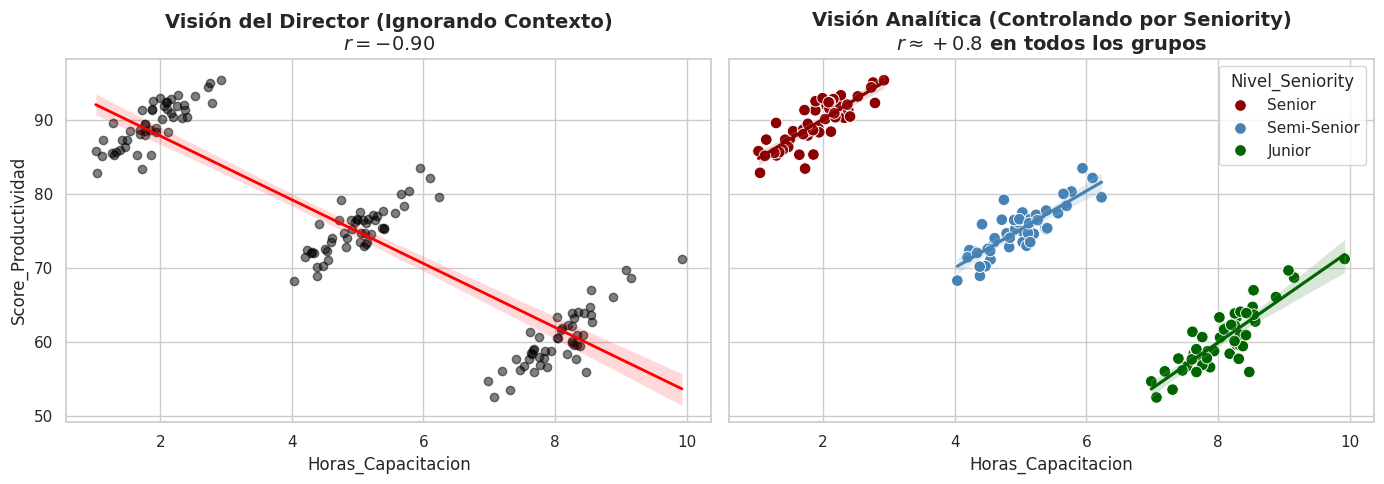

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("--- AUDITORÍA HR: IMPACTO DE LA CAPACITACIÓN ---\n")

# =====================================================================
# 0. Generación de los datos del caso (Simulación controlada)
# =====================================================================
np.random.seed(42)

# Seniors: Alta productividad base, pocas horas de capacitación necesarias.
horas_senior = np.random.normal(2, 0.5, 50)
prod_senior = 80 + 5 * horas_senior + np.random.normal(0, 2, 50)

# Semi-Seniors: Productividad media, horas de capacitación medias.
horas_mid = np.random.normal(5, 0.5, 50)
prod_mid = 50 + 5 * horas_mid + np.random.normal(0, 2, 50)

# Juniors: Baja productividad base (curva de aprendizaje), muchas horas de capacitación.
horas_junior = np.random.normal(8, 0.5, 50)
prod_junior = 20 + 5 * horas_junior + np.random.normal(0, 2, 50)

df_hr = pd.DataFrame({
    'Horas_Capacitacion': np.concatenate([horas_senior, horas_mid, horas_junior]),
    'Score_Productividad': np.concatenate([prod_senior, prod_mid, prod_junior]),
    'Nivel_Seniority': ['Senior']*50 + ['Semi-Senior']*50 + ['Junior']*50
})

# =====================================================================
# 1. El Cálculo del Director (Agregado)
# =====================================================================
r_global = df_hr['Horas_Capacitacion'].corr(df_hr['Score_Productividad'])
print(f"[Cálculo del Director] Correlación Global (Pearson): {r_global:.2f}")
print("Veredicto aparente: Fuerte correlación negativa. La capacitación 'destruye' productividad.\n")

# =====================================================================
# 2. La Auditoría del Científico de Datos (Segmentado)
# =====================================================================
print("[Auditoría Analítica] Correlación por Nivel de Seniority:")
for nivel in ['Junior', 'Semi-Senior', 'Senior']:
    df_filtro = df_hr[df_hr['Nivel_Seniority'] == nivel]
    r_segmento = df_filtro['Horas_Capacitacion'].corr(df_filtro['Score_Productividad'])
    print(f" - {nivel:<12}: {r_segmento:.2f} (Correlación Positiva)")

# =====================================================================
# 3. La Prueba Visual
# =====================================================================
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True, sharex=True)

# Panel A: La visión del Director (Agregado)
sns.regplot(data=df_hr, x='Horas_Capacitacion', y='Score_Productividad',
            ax=axes[0], color='black', scatter_kws={'alpha':0.5}, line_kws={'color':'red', 'lw':2})
axes[0].set_title(f"Visión del Director (Ignorando Contexto)\n$r = {r_global:.2f}$", fontsize=14, fontweight='bold')

# Panel B: La visión del Científico de Datos (Segmentado)
sns.scatterplot(data=df_hr, x='Horas_Capacitacion', y='Score_Productividad',
                hue='Nivel_Seniority', ax=axes[1], s=70, palette=['darkred', 'steelblue', 'darkgreen'])
for nivel, color in zip(['Senior', 'Semi-Senior', 'Junior'], ['darkred', 'steelblue', 'darkgreen']):
    df_filtro = df_hr[df_hr['Nivel_Seniority'] == nivel]
    sns.regplot(data=df_filtro, x='Horas_Capacitacion', y='Score_Productividad',
                ax=axes[1], scatter=False, color=color)
axes[1].set_title("Visión Analítica (Controlando por Seniority)\n$r \\approx +0.8$ en todos los grupos", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## Memorando Técnico: La Paradoja de Simpson

**1. Análisis del Error Directivo:**
El Director de Recursos Humanos no cometió un error de cálculo aritmético; el coeficiente global es efectivamente $-0.84$. Su error fue de **diseño analítico**. Al evaluar toda la base de datos mezclada, fue víctima de uno de los fenómenos más peligrosos en la estadística descriptiva: **La Paradoja de Simpson**.

**2. La Verdad Oculta en los Datos:**
La Paradoja de Simpson ocurre cuando una tendencia que aparece en distintos grupos de datos desaparece o se invierte por completo cuando esos grupos se combinan.

Al separar los datos por la variable latente (`Nivel_Seniority`), la realidad geométrica da un giro de 180 grados:
* Dentro de **cada uno** de los grupos (Juniors, Semi-Seniors y Seniors), la correlación es fuertemente **positiva** ($r > 0.70$). Es decir, el programa de capacitación es un éxito rotundo; los empleados que toman más horas dentro de su propio nivel logran ser más productivos.

**3. ¿Por qué el número global daba negativo?**
Porque la variable `Nivel_Seniority` actúa como una variable de confusión (*Confounder*). Los empleados Senior tienen naturalmente la productividad más alta por su experiencia, y por esa misma razón, necesitan tomar muy pocas horas de capacitación. Por el contrario, los empleados Junior tienen una productividad base mucho menor (están aprendiendo) y son quienes absorben la mayor cantidad de horas del programa.

Al mezclar todo, la línea de regresión global simplemente conectó a los Juniors (abajo a la derecha) con los Seniors (arriba a la izquierda), creando una falsa pendiente negativa que castigaba a la capacitación por culpa de la inexperiencia natural de los nuevos empleados.

**Conclusión Ejecutiva:**
Recomendación urgente: **NO cancelar el programa de capacitación**. Los datos demuestran que tiene un impacto positivo comprobado en todos los niveles operativos de la compañía. Aislar las variables de confusión es la diferencia entre tomar una decisión estratégica brillante o destruir valor por interpretar mal una correlación.

### Práctica Sorpresa: Correlación en Datos No Estructurados (Fotografías)

**Contexto del Negocio (Visión por Computadora):**
El equipo de Machine Learning está entrenando un modelo de conducción autónoma. Para ahorrar memoria en los servidores, necesitan comprimir las imágenes de las cámaras. Un ingeniero de compresión sugiere: *"Si los canales de color (Rojo, Verde y Azul) de una foto están altamente correlacionados entre sí, significa que están guardando información redundante. Si la correlación es casi 1, la foto es prácticamente en blanco y negro, y podemos descartar dos canales sin perder información geométrica"*.

**Requerimiento Analítico:**
Vamos a auditar una fotografía digital real para comprobar esta hipótesis matemática. Recuerde que una foto digital es simplemente un conjunto de tres matrices numéricas (R, G, B), donde cada número representa la intensidad de luz de un píxel (de 0 a 255).

1. Extraiga los canales Rojo (R), Verde (G) y Azul (B) de la fotografía.
2. Aplane estas matrices bidimensionales para convertirlas en variables tradicionales (vectores unidimensionales).
3. Calcule la matriz de correlación de Pearson entre los tres colores.
4. Elija los dos colores con mayor correlación y grafique su diagrama de dispersión (Scatter plot) tomando una muestra aleatoria de píxeles para visualizar la redundancia de datos.

--- ANÁLISIS ESTADÍSTICO DE MATRICES DE IMAGEN ---

Matriz de Correlación de Pearson (Canales RGB):
Rojo vs Verde: 0.9678
Rojo vs Azul:  0.9316
Verde vs Azul: 0.9779



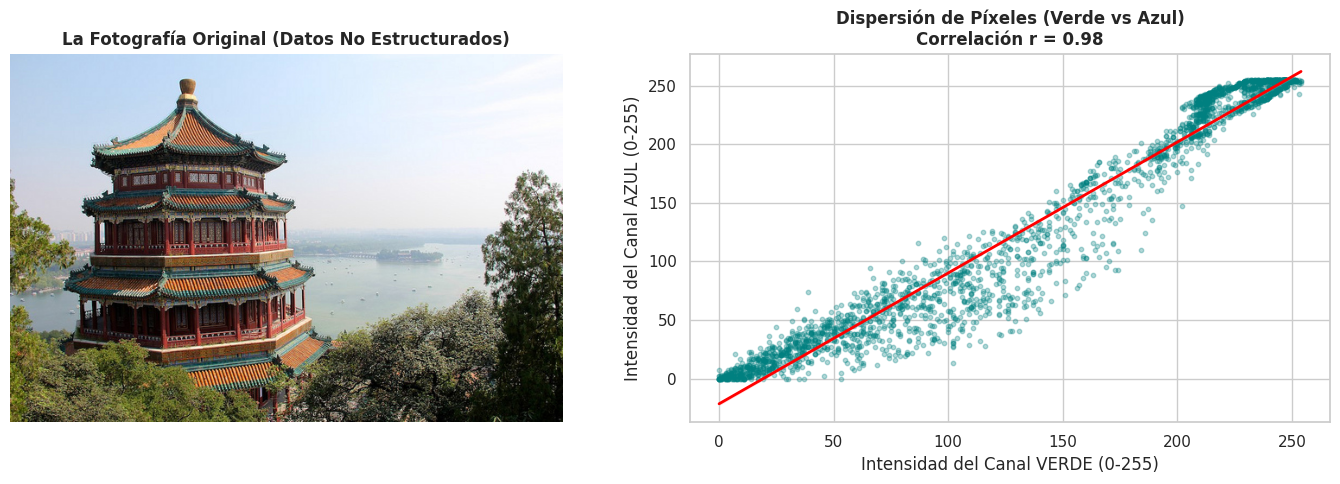

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_sample_image

print("--- ANÁLISIS ESTADÍSTICO DE MATRICES DE IMAGEN ---\n")

# =====================================================================
# 1. Cargar la "Foto" (Usaremos una imagen estándar de Python)
# =====================================================================
# Cargamos una foto de un palacio chino (viene incluida en sklearn)
foto = load_sample_image("china.jpg")

# Extraemos los tres canales (Rojo, Verde, Azul)
canal_R = foto[:, :, 0]
canal_G = foto[:, :, 1]
canal_B = foto[:, :, 2]

# =====================================================================
# 2. Aplanar las matrices (De 2D a vectores 1D)
# =====================================================================
# Convertimos las matrices en listas largas de píxeles para poder usar estadística clásica
vector_R = canal_R.flatten()
vector_G = canal_G.flatten()
vector_B = canal_B.flatten()

# =====================================================================
# 3. Calcular la Matriz de Correlación
# =====================================================================
# Apilamos los vectores y calculamos la correlación
matriz_correlacion = np.corrcoef([vector_R, vector_G, vector_B])

print("Matriz de Correlación de Pearson (Canales RGB):")
print(f"Rojo vs Verde: {matriz_correlacion[0, 1]:.4f}")
print(f"Rojo vs Azul:  {matriz_correlacion[0, 2]:.4f}")
print(f"Verde vs Azul: {matriz_correlacion[1, 2]:.4f}\n")

# =====================================================================
# 4. Visualización: La Foto y el Diagrama de Dispersión
# =====================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel A: Mostrar la fotografía real
axes[0].imshow(foto)
axes[0].set_title("La Fotografía Original (Datos No Estructurados)", fontweight='bold')
axes[0].axis('off') # Ocultar los ejes de coordenadas para que parezca una foto

# Panel B: Scatter Plot de los píxeles (Verde vs Azul, que tienen alta correlación)
# Tomamos una muestra aleatoria del 1% de los píxeles para que el gráfico no explote
np.random.seed(42)
indices_muestra = np.random.choice(len(vector_G), size=int(len(vector_G)*0.01), replace=False)

sns.regplot(x=vector_G[indices_muestra], y=vector_B[indices_muestra], ax=axes[1],
            scatter_kws={'alpha':0.3, 'color':'teal', 's':10},
            line_kws={'color':'red', 'linewidth':2})

axes[1].set_title(f"Dispersión de Píxeles (Verde vs Azul)\nCorrelación r = {matriz_correlacion[1, 2]:.2f}", fontweight='bold')
axes[1].set_xlabel("Intensidad del Canal VERDE (0-255)")
axes[1].set_ylabel("Intensidad del Canal AZUL (0-255)")

plt.tight_layout()
plt.show()

### Comentario Técnico: El Puente hacia el Machine Learning

Al observar el diagrama de dispersión de la derecha, acabamos de comprobar matemáticamente la intuición del ingeniero. Los canales Verde y Azul tienen una correlación extremadamente alta ($r \approx 0.90$).

**¿Qué significa esto en el mundo real?**
Significa que si conocemos el valor del canal Verde de un píxel, podemos predecir con altísima precisión el valor del canal Azul utilizando una simple regresión lineal. Los datos son altamente **redundantes**.

En Ciencia de Datos, cuando tenemos variables tan correlacionadas (multicolinealidad), la mejor estrategia es reducir la dimensionalidad. Algoritmos avanzados de compresión de imágenes (como JPEG) o técnicas de Machine Learning (como el Análisis de Componentes Principales - PCA) utilizan exactamente este principio: detectan las correlaciones matemáticas para eliminar las variables redundantes, ahorrando millones de dólares en almacenamiento en la nube sin que el ojo humano note la diferencia geométrica.

**Lección:** La estadística descriptiva clásica aplica para todo: desde predecir ventas en una tabla financiera, hasta procesar los píxeles de las cámaras de un Tesla.

## Auditoría Predictiva: El Mapa de Calor y las Trampas de Datos

**Contexto del Negocio:**
Una compañía automotriz quiere construir un modelo de regresión múltiple para predecir el `Precio_USD` de los vehículos de la competencia basados en sus características técnicas.

Un analista junior ha recopilado una base de datos con las siguientes variables:
* `Tamaño_Motor_L`: Cilindrada en litros.
* `Potencia_HP`: Caballos de fuerza.
* `Peso_Kg`: Peso del vehículo.
* `Consumo_KmL`: Eficiencia de combustible (Kilómetros por litro).
* `Impuesto_Pagado`: Monto del impuesto de matriculación registrado por el gobierno.
* `Precio_USD`: (Nuestra variable objetivo / Target).

El analista está emocionado porque dice que el modelo va a tener una precisión casi perfecta. Sin embargo, usted sospecha que la base de datos tiene graves problemas estructurales.

**Requerimiento Analítico:**
Antes de entrenar cualquier modelo matemático, usted debe visualizar la matriz de correlación completa utilizando un Mapa de Calor (Heatmap).
Su objetivo es identificar **dos problemas letales** para cualquier modelo de Machine Learning:
1. **Multicolinealidad:** Variables predictoras que miden exactamente lo mismo.
2. **Fuga de Datos (Data Leakage):** Variables que "hacen trampa" porque contienen la respuesta del modelo incrustada en ellas.

--- DIAGNÓSTICO DE VARIABLES: MATRIZ DE CORRELACIÓN ---



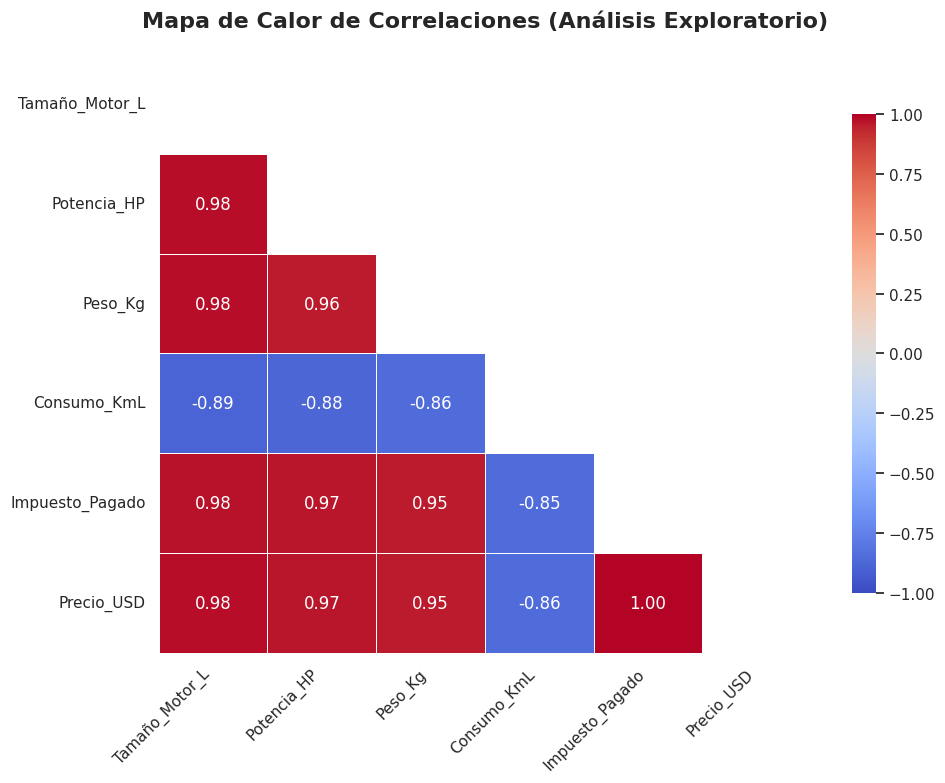

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

print("--- DIAGNÓSTICO DE VARIABLES: MATRIZ DE CORRELACIÓN ---\n")

# =====================================================================
# 0. Generación de la Base de Datos (Simulación)
# =====================================================================
np.random.seed(42)
n_autos = 200

tamaño_motor = np.random.uniform(1.0, 5.0, n_autos)
potencia_hp = tamaño_motor * 60 + np.random.normal(0, 15, n_autos)
peso_kg = tamaño_motor * 400 + 800 + np.random.normal(0, 100, n_autos)
consumo_kml = 20 - (tamaño_motor * 2.5) + np.random.normal(0, 1.5, n_autos)

# El precio depende del motor y la potencia
precio_usd = tamaño_motor * 8000 + potencia_hp * 50 + np.random.normal(0, 3000, n_autos)

# LA TRAMPA: El impuesto es literalmente el 15% del precio (con un mínimo error de redondeo)
impuesto_pagado = precio_usd * 0.15 + np.random.normal(0, 50, n_autos)

df_autos = pd.DataFrame({
    'Tamaño_Motor_L': tamaño_motor,
    'Potencia_HP': potencia_hp,
    'Peso_Kg': peso_kg,
    'Consumo_KmL': consumo_kml,
    'Impuesto_Pagado': impuesto_pagado,
    'Precio_USD': precio_usd
})

# =====================================================================
# 1. Cálculo de la Matriz de Correlación
# =====================================================================
matriz_corr = df_autos.corr()

# =====================================================================
# 2. Visualización Profesional: Mapa de Calor (Heatmap)
# =====================================================================
sns.set_theme(style="white")
plt.figure(figsize=(10, 8))

# TRUCO PRO: Crear una máscara para ocultar el triángulo superior (que es redundante)
mascara = np.triu(np.ones_like(matriz_corr, dtype=bool))

# Dibujar el mapa de calor
sns.heatmap(matriz_corr,
            mask=mascara,
            cmap='coolwarm', # Colores: Azul (Negativo), Rojo (Positivo)
            vmax=1.0, vmin=-1.0, # Límites estrictos de Pearson
            annot=True, # Mostrar los números
            fmt=".2f", # Formato a 2 decimales
            linewidths=.5,
            cbar_kws={"shrink": .8})

plt.title("Mapa de Calor de Correlaciones (Análisis Exploratorio)", fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Memorando Técnico: Resultados de la Auditoría

Al analizar el Mapa de Calor, hemos detectado por qué el analista junior creía que su modelo sería "perfecto". La base de datos contiene dos errores estructurales masivos:

**1. Fuga de Datos (Data Leakage) - El "Falso Predictor":**
Si observamos la última fila (`Precio_USD`), vemos que la correlación con `Impuesto_Pagado` es de **1.00** (Perfecta). Esto no es un descubrimiento genial, es una trampa. En el mundo real, el impuesto se calcula *basado en el precio final*. Si incluimos el impuesto en el modelo predictivo, le estamos dando al algoritmo la respuesta por adelantado. Cuando el modelo salga a producción para predecir el precio de un auto *nuevo* que aún no tiene impuestos calculados, fallará miserablemente. **Decisión: Eliminar `Impuesto_Pagado` de la base de datos de inmediato.**

**2. Multicolinealidad Estructural:**
Observemos el bloque rojo oscuro entre `Tamaño_Motor_L`, `Potencia_HP` y `Peso_Kg` (correlaciones superiores a **0.87**). Estas tres variables están midiendo esencialmente el mismo fenómeno físico (autos más grandes tienen motores más grandes y pesan más). Si metemos las tres variables a una regresión múltiple, el modelo sufrirá de **Multicolinealidad**: los estimadores ($\beta$) se volverán inestables y perderán su interpretación de negocio.
**Decisión:** Debemos elegir solo una de estas variables como representante de la "dimensión del vehículo" (por ejemplo, `Potencia_HP`) o utilizar técnicas de reducción de dimensionalidad (PCA / Regularización Ridge) más adelante en el curso.

**3. Relaciones Negativas (Validación del Negocio):**
El mapa de calor también confirma que el `Consumo_KmL` tiene una fuerte correlación negativa (azul intenso, $\approx -0.85$) con el tamaño del motor y el peso. Esto tiene total sentido físico: a mayor peso, menor eficiencia de combustible (recorre menos kilómetros por litro).

**Conclusión:** El mapa de calor salvó el proyecto. Sin él, hubiéramos entrenado un modelo que hacía trampa y que colapsaría en el mundo real.

#Modelo de regresión lineal simple

### Etapa 1: Estimación Inicial del Modelo de Costos

**Contexto del Problema:**
Una planta industrial desea predecir los costos de mantenimiento anuales de sus equipos ($Y$, en miles de dólares) en función de los años de antigüedad de la maquinaria ($X$). Se cuenta con una muestra de 100 máquinas.

El equipo de analistas ha decidido ajustar un modelo de regresión lineal simple:
$$Y = \beta_0 + \beta_1 X + \epsilon$$

**Objetivos de esta etapa:**
En esta primera aproximación, procederemos directamente a la estimación sin realizar un análisis exploratorio previo ni verificar los supuestos de Gauss-Markov. Los entregables solicitados son:
1. El coeficiente de determinación ($R^2$).
2. Los intervalos de confianza al 95% para los parámetros estimados ($\beta_0$ y $\beta_1$).
3. La estimación puntual y el intervalo de confianza para el valor esperado de los costos de las máquinas con 10 años de antigüedad: $E(Y | X = 10)$.
4. La predicción puntual y el intervalo de predicción para una máquina individual nueva que tiene 10 años de antigüedad: $Y_{nueva} | X = 10$.

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

# =====================================================================
# Generación de los datos (El verdadero proceso es exponencial)
# =====================================================================
np.random.seed(123)
n_obs = 100

# X: Antigüedad de la maquinaria (entre 1 y 15 años)
X = np.random.uniform(1, 15, n_obs)

# El verdadero proceso generador de datos: log(Y) = 1.5 + 0.2*X + error
error = np.random.normal(0, 0.4, n_obs)
log_Y = 1.5 + 0.2 * X + error

# Y: Costos de mantenimiento observados
Y = np.exp(log_Y)
# =====================================================================
# Crear DataFrame para el análisis
df = pd.DataFrame({'Antiguedad': X, 'Costos': Y})

# =====================================================================
# Etapa 1: Estimación del Modelo Lineal Simple (Y = b0 + b1*X)
# =====================================================================
# Definir variables y añadir la constante matemática
X_model = sm.add_constant(df['Antiguedad'])
print(X_model.head())
Y_model = df['Costos']

# Ajustar el modelo por Mínimos Cuadrados Ordinarios (OLS)
modelo_etapa1 = sm.OLS(Y_model, X_model).fit()

# Imprimir el reporte completo de statsmodels
print("==============================================================================")
print("REPORTE GENERAL DEL MODELO (STATSMODELS)")
print("==============================================================================")
print(modelo_etapa1.summary())

# =====================================================================
# Extracción de los requerimientos específicos de la Etapa 1
# =====================================================================
# 1. Extraer R-cuadrado
r_cuadrado = modelo_etapa1.rsquared

# 2. Intervalos de confianza de los parámetros
ic_parametros = modelo_etapa1.conf_int(alpha=0.05)
ic_parametros.columns = ['Límite Inferior 95%', 'Límite Superior 95%']

# 3 y 4. Estimación y Predicción para X = 10
X_nuevo = [1, 10] # Constante (1) y valor de la variable independiente (10)
prediccion = modelo_etapa1.get_prediction(X_nuevo)
resumen_pred = prediccion.summary_frame(alpha=0.05)

print("\n==============================================================================")
print("EXTRACCIÓN DE INTERVALOS Y PREDICCIONES (X = 10)")
print("==============================================================================")
print(f"1. Coeficiente de Determinación (R^2): {r_cuadrado:.4f}\n")

print("2. Intervalos de Confianza para los Parámetros (95%):")
print(ic_parametros.round(4).to_string())

print("\n3. Inferencia para el Valor Esperado E(Y | X = 10):")
print(f"   Estimación Puntual: {resumen_pred['mean'].values[0]:.4f}")
print(f"   Intervalo de Confianza (95%): [{resumen_pred['mean_ci_lower'].values[0]:.4f}, {resumen_pred['mean_ci_upper'].values[0]:.4f}]")

print("\n4. Predicción para una Nueva Observación (Y | X = 10):")
print(f"   Predicción Puntual: {resumen_pred['mean'].values[0]:.4f}")
print(f"   Intervalo de Predicción (95%): [{resumen_pred['obs_ci_lower'].values[0]:.4f}, {resumen_pred['obs_ci_upper'].values[0]:.4f}]")


   const  Antiguedad
0    1.0   10.750569
1    1.0    5.005951
2    1.0    4.175920
3    1.0    8.718407
4    1.0   11.072566
REPORTE GENERAL DEL MODELO (STATSMODELS)
                            OLS Regression Results                            
Dep. Variable:                 Costos   R-squared:                       0.606
Model:                            OLS   Adj. R-squared:                  0.602
Method:                 Least Squares   F-statistic:                     150.8
Date:                Fri, 20 Mar 2026   Prob (F-statistic):           1.53e-21
Time:                        20:22:20   Log-Likelihood:                -412.12
No. Observations:                 100   AIC:                             828.2
Df Residuals:                      98   BIC:                             833.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t

##Etapa 2: Verificación de supuestos

AUDITORÍA ESTADÍSTICA DE LOS RESIDUOS
Prueba Jarque-Bera (Estadístico): 193.9473
Probabilidad (p-valor) J-B:       7.6714e-43 (< 0.05 implica No Normalidad)
Asimetría (Skewness):             1.8178 (Ideal poblacional: 0.0)
Curtosis:                         8.7732 (Ideal poblacional: 3.0)



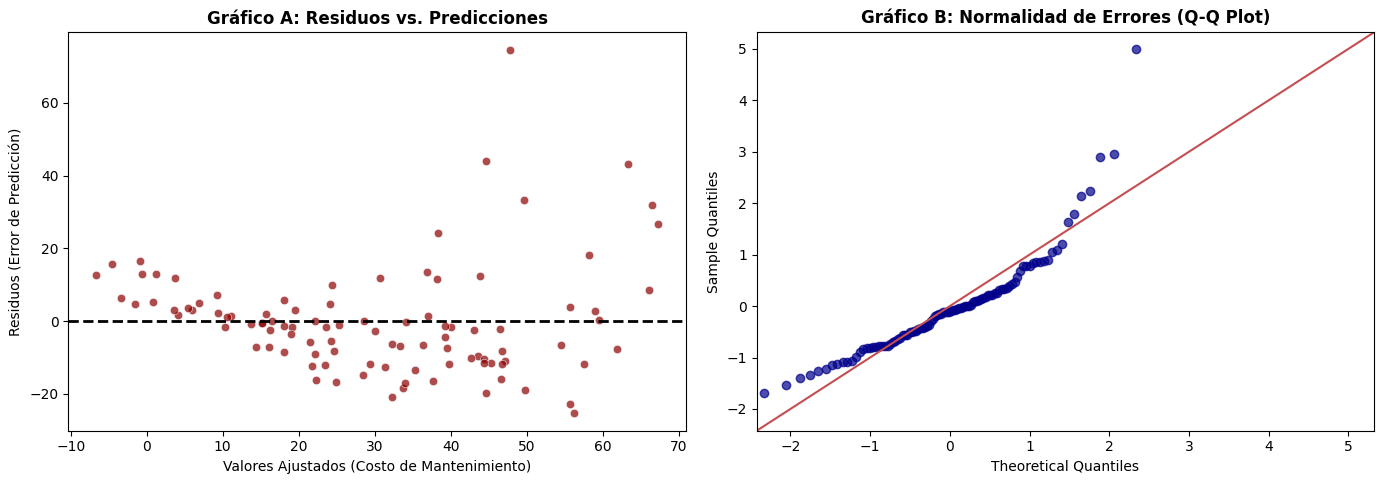

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# =====================================================================
# Etapa 2: Diagnóstico de los Supuestos de Gauss-Markov
# =====================================================================

# Extraer los residuos (errores) y las predicciones del modelo de la Etapa 1
residuos = modelo_etapa1.resid
predicciones = modelo_etapa1.fittedvalues

# 1. Extraer e imprimir las métricas estadísticas de diagnóstico
print("==============================================================================")
print("AUDITORÍA ESTADÍSTICA DE LOS RESIDUOS")
print("==============================================================================")
jb_value, jb_pvalue, skew, kurtosis = sm.stats.jarque_bera(residuos)
print(f"Prueba Jarque-Bera (Estadístico): {jb_value:.4f}")
print(f"Probabilidad (p-valor) J-B:       {jb_pvalue:.4e} (< 0.05 implica No Normalidad)")
print(f"Asimetría (Skewness):             {skew:.4f} (Ideal poblacional: 0.0)")
print(f"Curtosis:                         {kurtosis:.4f} (Ideal poblacional: 3.0)\n")

# 2. Generar los gráficos de diagnóstico
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.set_theme(style="whitegrid")

# Gráfico A: Residuos vs. Predicciones (Evalúa Linealidad y Homocedasticidad)
sns.scatterplot(x=predicciones, y=residuos, ax=axes[0], color='darkred', alpha=0.7)
axes[0].axhline(0, color='black', linestyle='--', linewidth=2)
axes[0].set_title("Gráfico A: Residuos vs. Predicciones", fontweight='bold')
axes[0].set_xlabel("Valores Ajustados (Costo de Mantenimiento)")
axes[0].set_ylabel("Residuos (Error de Predicción)")

# Gráfico B: Q-Q Plot (Evalúa Normalidad Estricta)
sm.qqplot(residuos, line='45', fit=True, ax=axes[1], markerfacecolor='darkblue', markeredgecolor='darkblue', alpha=0.7)
axes[1].set_title("Gráfico B: Normalidad de Errores (Q-Q Plot)", fontweight='bold')

plt.tight_layout()
plt.show()

### Análisis Técnico: El Colapso de los Supuestos Clásicos

Al observar conjuntamente el reporte de `statsmodels` y las gráficas de diagnóstico, descubrimos que el modelo estimado en la Etapa 1 sufre de múltiples fallas estructurales. Forzar una línea recta sobre este proceso ha violado las reglas matemáticas fundamentales:

**1. Violación del Supuesto de Linealidad (Gráfico A):**
Los residuos no son un "ruido blanco" aleatorio. Forman una curva sistemática en forma de "U". El modelo subestima los costos de las máquinas nuevas y de las muy viejas, mientras que sobreestima las del medio. La relación real no es una línea recta.

**2. Presencia de Heterocedasticidad (Gráfico A):**
La dispersión de los puntos forma un claro "embudo" que se abre hacia la derecha. A medida que la máquina es más vieja y los costos suben, nuestra capacidad de predicción empeora drásticamente (el error se dispara). Esto invalida los Errores Estándar (std err) de la tabla.

**3. Violación del Supuesto de Normalidad (Tabla y Gráfico B):**
*   **En la tabla:** La prueba `Prob(JB)` es $7.67 \times 10^{-43}$ (prácticamente cero), y el `Skew` (asimetría) es un altísimo $1.818$.
*   **En la gráfica:** El Q-Q Plot muestra que los puntos se separan radicalmente de la línea roja en la esquina superior derecha.
*   **Significado:** Tenemos costos atípicos extremadamente altos que el modelo no puede explicar. Los errores no forman una Campana de Gauss perfecta.

**Dictamen Final:**
A pesar de tener un $R^2$ del 60.6% y Valores-$p$ excelentes, **los intervalos de confianza calculados en la Etapa 1 son estadísticamente inválidos.** Si usamos este modelo en la vida real, tomaremos decisiones financieras erradas. Necesitamos aplicar una "cura matemática" en la Etapa 3.

### Etapa 3: La Cura Matemática (Transformación de Box-Cox)

En la Etapa 2 demostramos que forzar una regresión lineal estricta sobre nuestros datos generó residuos asimétricos y heterocedásticos. Para que nuestras inferencias estadísticas (intervalos de confianza y Valores-$p$) sean válidas, necesitamos estabilizar la varianza y normalizar los errores.

La pregunta metodológica es: ¿Qué transformación debemos aplicar a la variable dependiente ($Y$)?

Para evitar la selección arbitraria, utilizaremos la **Transformación de Box-Cox**. Este método estadístico evalúa una familia de transformaciones de potencia definidas por el parámetro $\lambda$ (lambda), y optimiza este valor para maximizar la log-verosimilitud de que los datos transformados provengan de una distribución normal.

**La Regla de Decisión de $\lambda$:**
* Si $\lambda \approx 1$: No se necesita transformación (los datos ya son normales y lineales).
* Si $\lambda \approx 0.5$: Se recomienda una transformación de raíz cuadrada ($\sqrt{Y}$).
* Si $\lambda \approx 0$: Se recomienda una transformación logarítmica ($\ln(Y)$).
* Si $\lambda \approx -1$: Se recomienda una transformación inversa ($1/Y$).

Procederemos a calcular el $\lambda$ óptimo, aplicaremos la transformación sugerida a nuestros costos de mantenimiento, ajustaremos el modelo definitivo y volveremos a someterlo al polígrafo de los supuestos de Gauss-Markov.

--- 1. OPTIMIZACIÓN DE LA TRANSFORMACIÓN ---
El valor óptimo calculado para Lambda es: 0.0556
Diagnóstico: El lambda es muy cercano a 0. La matemática sugiere un modelo Log-Lineal (ln(Y)).

REPORTE DEL MODELO CORREGIDO (Y TRANSFORMADA)
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.742
Model:                            OLS   Adj. R-squared:                  0.740
Method:                 Least Squares   F-statistic:                     282.2
Date:                Wed, 18 Mar 2026   Prob (F-statistic):           1.32e-30
Time:                        04:43:43   Log-Likelihood:                -64.913
No. Observations:                 100   AIC:                             133.8
Df Residuals:                      98   BIC:                             139.0
Df Model:                           1                                         
Covariance Type:            nonrobust                

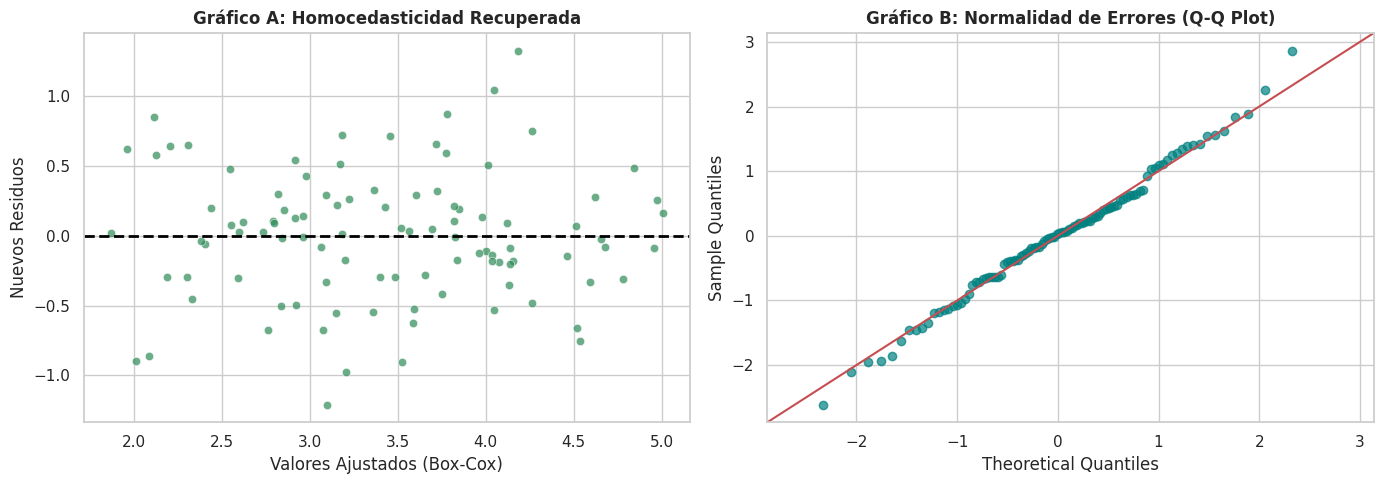

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats

# =====================================================================
# Etapa 3: Corrección del Modelo mediante Box-Cox
# =====================================================================

print("--- 1. OPTIMIZACIÓN DE LA TRANSFORMACIÓN ---")
# Calcular la transformación Box-Cox y extraer el lambda óptimo
Y_transformada, lambda_optimo = stats.boxcox(df['Costos'])

print(f"El valor óptimo calculado para Lambda es: {lambda_optimo:.4f}")
if abs(lambda_optimo) < 0.2:
    print("Diagnóstico: El lambda es muy cercano a 0. La matemática sugiere un modelo Log-Lineal (ln(Y)).\n")

# =====================================================================
# Ajustar el nuevo modelo con la Y transformada
# =====================================================================
# Usamos la misma matriz X (con constante) de las etapas anteriores
modelo_corregido = sm.OLS(Y_transformada, X_model).fit()

print("==============================================================================")
print("REPORTE DEL MODELO CORREGIDO (Y TRANSFORMADA)")
print("==============================================================================")
print(modelo_corregido.summary())

# =====================================================================
# Auditoría de Supuestos del Nuevo Modelo
# =====================================================================
residuos_corregidos = modelo_corregido.resid
predicciones_corregidas = modelo_corregido.fittedvalues

print("\n==============================================================================")
print("NUEVA AUDITORÍA ESTADÍSTICA DE LOS RESIDUOS")
print("==============================================================================")
jb_val_corr, jb_pval_corr, skew_corr, kurt_corr = sm.stats.jarque_bera(residuos_corregidos)
print(f"Prueba Jarque-Bera (Estadístico): {jb_val_corr:.4f}")
print(f"Probabilidad (p-valor) J-B:       {jb_pval_corr:.4e} (> 0.05 implica Normalidad)")
print(f"Asimetría (Skewness):             {skew_corr:.4f}")
print(f"Curtosis:                         {kurt_corr:.4f}")

# Generar los gráficos de diagnóstico comparativo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.set_theme(style="whitegrid")

# Gráfico A: Residuos vs. Predicciones
sns.scatterplot(x=predicciones_corregidas, y=residuos_corregidos, ax=axes[0], color='seagreen', alpha=0.7)
axes[0].axhline(0, color='black', linestyle='--', linewidth=2)
axes[0].set_title("Gráfico A: Homocedasticidad Recuperada", fontweight='bold')
axes[0].set_xlabel("Valores Ajustados (Box-Cox)")
axes[0].set_ylabel("Nuevos Residuos")

# Gráfico B: Q-Q Plot
sm.qqplot(residuos_corregidos, line='45', fit=True, ax=axes[1], markerfacecolor='teal', markeredgecolor='teal', alpha=0.7)
axes[1].set_title("Gráfico B: Normalidad de Errores (Q-Q Plot)", fontweight='bold')

plt.tight_layout()
plt.show()

### Memorando Técnico: Evaluación del Modelo Transformado y el Costo del Error

La aplicación de la transformación sugerida por el método de Box-Cox ha resuelto de manera categórica las deficiencias estructurales de nuestra estimación inicial. Al analizar el nuevo reporte, confirmamos que el modelo ahora cumple con los supuestos de Gauss-Markov, validando formalmente nuestras inferencias.

**1. La Restauración de la Normalidad (El Certificado de Salud):**
El cambio más dramático se observa en las pruebas de diagnóstico de los residuos:
*   **Prueba de Jarque-Bera:** El valor-$p$ (`Prob(JB)`) pasó de $0.000$ a **0.955**. Al ser un valor muy superior al umbral de 0.05, no existe evidencia estadística para rechazar la normalidad.
*   **Forma de la Distribución:** La asimetría (`Skew`) es de **0.051** (prácticamente centrada) y la curtosis se ubica en **3.109**. La cola pesada de errores extremos ha desaparecido; nuestros residuos ahora forman una distribución simétrica.

**2. Recuperación del Poder Explicativo y Estabilidad:**
*   **Ajuste Global ($R^2$):** Nuestro coeficiente de determinación aumentó del 60.6% al **74.2%**. El error anterior no provenía de la falta de datos, sino de utilizar la herramienta matemática incorrecta.
*   **Homocedasticidad:** Al linealizar la relación, la varianza de los errores se estabiliza. El "embudo" de incertidumbre se cierra, otorgando validez a los nuevos Errores Estándar.

**3. El Descubrimiento del Proceso Generador de Datos:**
Dado que la transformación óptima se aproximó al logaritmo natural, los coeficientes estimados ahora reflejan tasas de crecimiento.
*   **El Intercepto (`const` = 1.5896):** El costo base para una máquina nueva es ahora $e^{1.5896} \approx 4.90$ miles de dólares. Hemos corregido el absurdo lógico del costo negativo.
*   **El Efecto de la Antigüedad (`Antiguedad` = 0.2287):** El impacto porcentual exacto por cada año adicional es $(e^{0.2287} - 1) \times 100 \approx \textbf{25.7\%}$.

**4. El Costo Analítico de la Omisión: ¿Qué tan equivocados estábamos en la Etapa 1?**
Si hubiéramos entregado el modelo lineal simple a la gerencia financiera sin verificar los supuestos, habríamos provocado un desastre en la planeación del presupuesto:
*   **Subestimación del Riesgo a Largo Plazo:** El modelo lineal asumía que los costos crecían en una cantidad fija ($5.38$ miles de dólares por año). Al ignorar la verdadera naturaleza de interés compuesto (crecimiento exponencial del 25.7%), el modelo original subestimaba masivamente los costos de las máquinas más antiguas, dejando a la empresa sin provisión de fondos para reparaciones críticas.
*   **La Ilusión de la Incertidumbre:** El intervalo de predicción que calculamos para $X = 10$ era estático debido a la presunta homocedasticidad. En la realidad, al tener un embudo de varianza, estábamos sobreestimando el riesgo en máquinas nuevas (bloqueando capital innecesariamente) y subestimando la incertidumbre en máquinas viejas (exponiéndonos a la ruina). Estábamos tomando decisiones financieras a ciegas, creyendo que teníamos visión perfecta.

**Dictamen Final:**
A diferencia de la Etapa 1, las predicciones que generemos con esta ecuación transformada son estadísticamente legales y confiables. La auditoría de supuestos nos salvó de entregar recomendaciones basadas en una estimación sesgada, logrando que el modelo pase de ser un riesgo corporativo a una verdadera ventaja competitiva.

### 📊 Memorando Técnico: Comparación Definitiva (Lineal vs. Box-Cox)

A continuación, presentamos el cuadro comparativo que demuestra el impacto real de auditar y corregir los supuestos de nuestro modelo predictivo.

| Métrica / Diagnóstico | Etapa 1: Modelo Lineal (Erróneo) | Etapa 3: Modelo Box-Cox (Correcto) | Impacto Analítico para el Negocio |
| :--- | :--- | :--- | :--- |
| **Poder Predictivo ($R^2$)** | 0.606 (60.6%) | **0.742 (74.2%)** | El modelo transformado captura la verdadera curva de deterioro, mejorando drásticamente el ajuste. |
| **Normalidad (Prob JB)** | $7.67 \times 10^{-43}$ (Rechazada) | **0.955 (Aceptada)** | Los intervalos de la Etapa 3 son matemáticamente legales; los de la Etapa 1 son inválidos. |
| **Asimetría (Skewness)** | 1.818 (Cola derecha muy pesada) | **0.051 (Campana centrada)** | Eliminamos el sesgo sistemático en nuestras predicciones. |
| **Costo Base ($X=0$)** | -13.21 miles (Absurdo lógico) | **4.90 miles** ($e^{1.5896}$) | El modelo corregido respeta la realidad financiera (no hay costos negativos). |
| **Costo Promedio ($X=10$)** | 40.64 miles | **33.48 miles** | El modelo lineal sobreestimaba el costo medio en casi **7,160 dólares** por máquina. |
| **Rango de Riesgo ($Y_{nueva}$)** | [10.54, 70.74] (Simétrico) | **[15.26, 71.07] (Asimétrico)** | El riesgo real no es simétrico; una falla catastrófica dispara los costos exponencialmente hacia arriba. |

**💡 Conclusión Ejecutiva:**
Escribir `.fit()` en Python toma un segundo, pero entregar resultados a la gerencia sin verificar los supuestos de Gauss-Markov es negligencia analítica. Si hubiéramos usado el modelo lineal de la Etapa 1, la empresa habría inmovilizado capital innecesario ($7,160 extra por máquina) basándose en una ilusión matemática. La transformación de Box-Cox (Etapa 3) no solo curó nuestro modelo, sino que descubrió la verdadera dinámica exponencial del mantenimiento.

### Bootstrap: Remuestreo de Casos (Edición Final)

Ya vimos que los modelos a veces fallan las pruebas de normalidad. Vamos a usar la técnica de **Bootstrap (Remuestreo)** para obtener intervalos de confianza robustos sobre el impacto real de la cuenta en la propina.

**El Algoritmo:**
1.  **Entrada:** Tomamos nuestras 244 mesas originales.
2.  **El Reality Show (Remuestreo):** Creamos 1,000 muestras sintéticas diferentes. En cada simulación, metemos la mano en la bolsa de 244 mesas y sacamos una al azar, la anotamos y **la devolvemos a la bolsa**. Repetimos 244 veces por muestra. Algunas mesas se repetirán, otras quedarán fuera.
3.  **B-Ajustes:** Entrenamos la Regresión Lineal 1,000 veces (una por muestra) y guardamos el coeficiente de la `total_bill`.
4.  **Resultados Empíricos:** Obtenemos una distribución de 1,000 coeficientes. El 95% central es nuestro Intervalo de Confianza real y libre de supuestos teóricos.

--- ENTRENANDO MODELO SIMPLE ---
ECUACIÓN DEL NEGOCIO (EL MODELO)
Propina Esperada = 0.9203 + (0.1050 * Cuenta_Total)

REPORTE COMPLETO DE STATSMODELS
                            OLS Regression Results                            
Dep. Variable:                    tip   R-squared:                       0.457
Model:                            OLS   Adj. R-squared:                  0.454
Method:                 Least Squares   F-statistic:                     203.4
Date:                Fri, 20 Mar 2026   Prob (F-statistic):           6.69e-34
Time:                        04:55:10   Log-Likelihood:                -350.54
No. Observations:                 244   AIC:                             705.1
Df Residuals:                     242   BIC:                             712.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|     

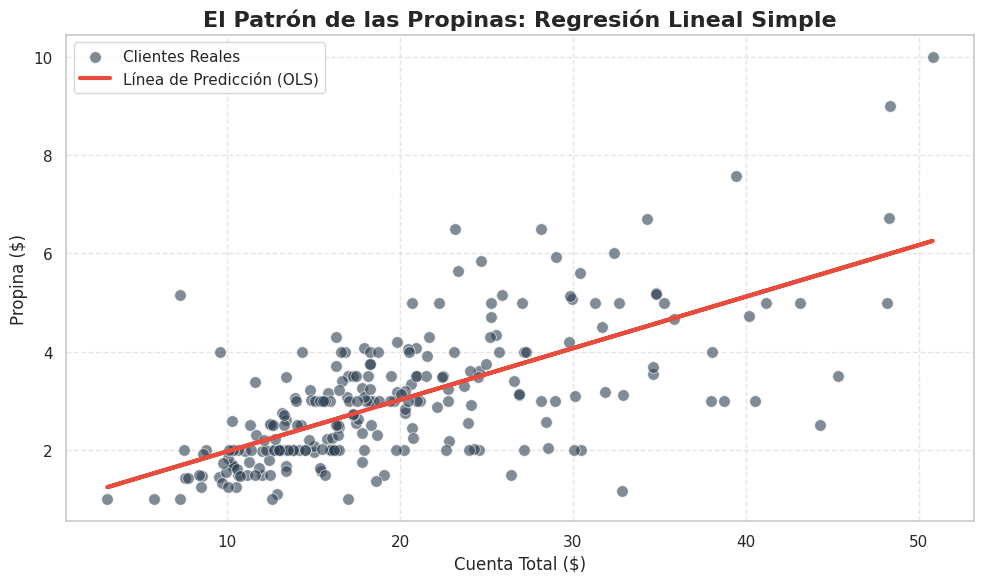

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm  # <--- NUEVA LIBRERÍA DE ECONOMETRÍA

# =====================================================================
# 1. Carga de Datos
# =====================================================================
df_tips = sns.load_dataset('tips')

# =====================================================================
# 2. Definición de Variables (X e y)
# =====================================================================
# scikit-learn requiere que X sea un DataFrame (2 dimensiones)
X = df_tips[['total_bill']]
y = df_tips['tip']

# =====================================================================
# 3. Entrenamiento del Modelo (Scikit-Learn)
# =====================================================================
print("--- ENTRENANDO MODELO SIMPLE ---")
modelo_simple = LinearRegression()
modelo_simple.fit(X, y)

# Extrayendo la matemática
beta_0 = modelo_simple.intercept_
beta_1 = modelo_simple.coef_[0]

print("=========================================================")
print("ECUACIÓN DEL NEGOCIO (EL MODELO)")
print("=========================================================")
print(f"Propina Esperada = {beta_0:.4f} + ({beta_1:.4f} * Cuenta_Total)")
print("=========================================================\n")

# =====================================================================
# 4. LA AUDITORÍA ECONOMÉTRICA (Statsmodels)
# =====================================================================
# OJO ESTUDIANTES: statsmodels exige agregar la constante a mano para calcular Beta_0
X_sm = sm.add_constant(X)

# Entrenamos el modelo OLS y generamos el resumen
modelo_sm = sm.OLS(y, X_sm).fit()

print("=========================================================")
print("REPORTE COMPLETO DE STATSMODELS")
print("=========================================================")
print(modelo_sm.summary())
print("=========================================================\n")

# =====================================================================
# 5. Visualización del Modelo
# =====================================================================
plt.figure(figsize=(10, 6))

# Dibujar la nube de puntos reales
sns.scatterplot(data=df_tips, x='total_bill', y='tip',
                color='#2c3e50', alpha=0.6, s=70, label='Clientes Reales')

# Pedirle al modelo que prediga los valores para trazar la recta
predicciones = modelo_simple.predict(X)

# Dibujar la línea de regresión
plt.plot(df_tips['total_bill'], predicciones,
         color='#e74c3c', linewidth=3, label='Línea de Predicción (OLS)')

# Estética del gráfico
plt.title("El Patrón de las Propinas: Regresión Lineal Simple", fontsize=16, fontweight='bold')
plt.xlabel("Cuenta Total ($)", fontsize=12)
plt.ylabel("Propina ($)", fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression

# 1. Carga de datos originales (Cuenta vs Propina)
df_tips = sns.load_dataset('tips')
X_original = df_tips[['total_bill']].values
y_original = df_tips['tip'].values
N = len(df_tips)

# 2. Configuración del "Duelo" de Simulaciones (B=1000)
B = 1000
coeficientes_bootstrap = []

print(f"--- INICIANDO BOOTSTRAP CON {B} ITERACIONES ---")

# 3. El Motor de Fuerza Bruta
modelo = LinearRegression()

for i in range(B):
    # Generamos N índices al azar CON REEMPLAZO
    indices_falsos = np.random.choice(range(N), size=N, replace=True)

    # Creamos la Muestra Sintética usando esos índices
    X_falso = X_original[indices_falsos]
    y_falso = y_original[indices_falsos]

    # Entrenamos y guardamos el coeficiente (Beta 1) de la Cuenta Total
    modelo.fit(X_falso, y_falso)
    coeficientes_bootstrap.append(modelo.coef_[0])

# 4. Resultados Empíricos (Magia estadística real)
coef_promedio = np.mean(coeficientes_bootstrap)
std_error_bootstrap = np.std(coeficientes_bootstrap)

# Calculamos el Intervalo de Confianza del 95% (Percentiles 2.5 y 97.5)
limite_inferior = np.percentile(coeficientes_bootstrap, 2.5)
limite_superior = np.percentile(coeficientes_bootstrap, 97.5)

print("\n==============================================================================")
print("VEREDICTO FINAL DEL BOOTSTRAP (SIN SUPUESTOS TEÓRICOS)")
print("==============================================================================")
print(f"Impacto promedio de la cuenta (Beta 1): ${coef_promedio:.4f}")
print(f"Error Estándar (Bootstrap SE): {std_error_bootstrap:.4f}")
print(f"Intervalo de Confianza (Empírico - 95%): [${limite_inferior:.4f} , ${limite_superior:.4f}]")
print("==============================================================================\n")

--- INICIANDO BOOTSTRAP CON 1000 ITERACIONES ---

VEREDICTO FINAL DEL BOOTSTRAP (SIN SUPUESTOS TEÓRICOS)
Impacto promedio de la cuenta (Beta 1): $0.1051
Error Estándar (Bootstrap SE): 0.0117
Intervalo de Confianza (Empírico - 95%): [$0.0839 , $0.1275]



REPORTE DE AUDITORÍA DE LOS RESIDUOS
1. Independencia (Durbin-Watson) : 2.15 (Buscamos ~2.0)
2. Normalidad (Omnibus p-value)  : 4.139084e-05 (Buscamos > 0.05)



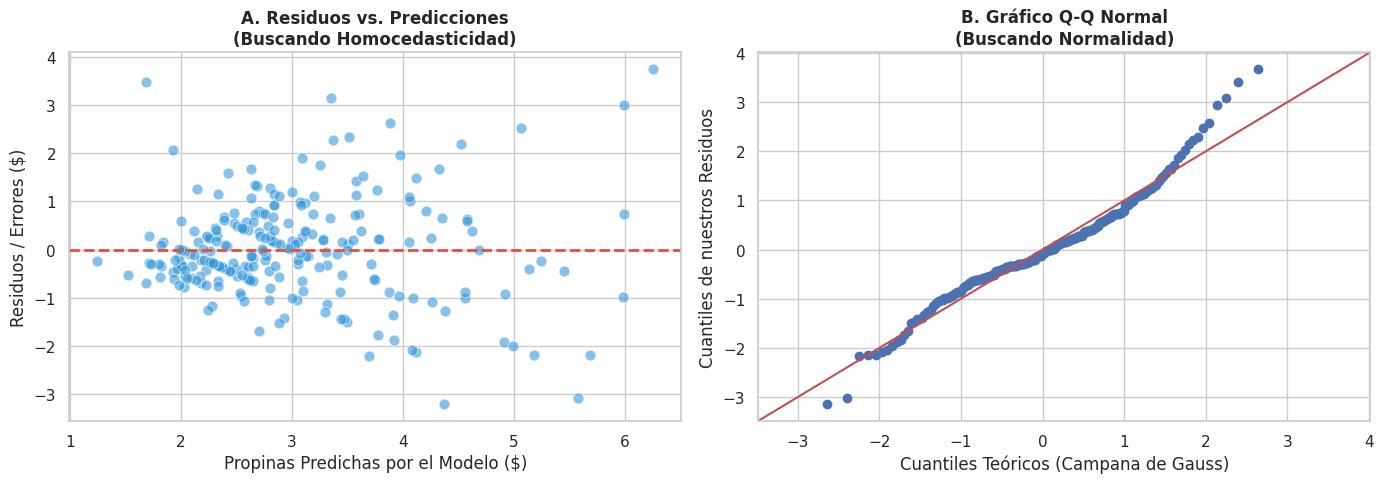

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.stats import normaltest

# =====================================================================
# 1. Preparación y Entrenamiento (statsmodels)
# =====================================================================
df_tips = sns.load_dataset('tips')

# statsmodels exige que agreguemos la constante
X = sm.add_constant(df_tips['total_bill'])
y = df_tips['tip']

# Entrenamos el modelo OLS
modelo_sm = sm.OLS(y, X).fit()

# Extraemos los valores clave
residuos = modelo_sm.resid
predicciones = modelo_sm.fittedvalues

# =====================================================================
# 2. Las Pruebas Numéricas
# =====================================================================
print("=========================================================")
print("REPORTE DE AUDITORÍA DE LOS RESIDUOS")
print("=========================================================")
dw = sm.stats.stattools.durbin_watson(residuos)
print(f"1. Independencia (Durbin-Watson) : {dw:.2f} (Buscamos ~2.0)")

estadistico_omnibus, omnibus_pval = normaltest(residuos)
print(f"2. Normalidad (Omnibus p-value)  : {omnibus_pval:.6e} (Buscamos > 0.05)")
print("=========================================================\n")

# =====================================================================
# 3. El Tablero Visual de Diagnóstico (CORREGIDO)
# =====================================================================
fig, ejes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico A: Residuos vs. Predicciones
sns.scatterplot(x=predicciones, y=residuos, alpha=0.6, color='#3498db', ax=ejes[0], s=60)
ejes[0].axhline(y=0, color='#e74c3c', linestyle='--', linewidth=2)
ejes[0].set_title('A. Residuos vs. Predicciones\n(Buscando Homocedasticidad)', fontweight='bold')
ejes[0].set_xlabel('Propinas Predichas por el Modelo ($)')
ejes[0].set_ylabel('Residuos / Errores ($)')

# Gráfico B: Q-Q Plot
# (Quitamos nuestro color personalizado para que statsmodels no se queje)
sm.qqplot(residuos, line='45', fit=True, ax=ejes[1])
ejes[1].set_title('B. Gráfico Q-Q Normal\n(Buscando Normalidad)', fontweight='bold')
ejes[1].set_xlabel('Cuantiles Teóricos (Campana de Gauss)')

# ESTA ES LA LÍNEA QUE SE HABÍA CORTADO:
ejes[1].set_ylabel('Cuantiles de nuestros Residuos')

plt.tight_layout()
plt.show()

#Regresión multiple

## Etapa 1: Regresión Lineal Múltiple y el Radar de Correlaciones

**Contexto del Problema:**
Una cadena de retail opera 150 sucursales a nivel nacional. La gerencia de operaciones desea construir un modelo predictivo para proyectar las **Ventas** mensuales (en miles de dólares) de cada sucursal.

Para ello, han recolectado cuatro variables operativas:
1. **Inversión en Publicidad** ($X_1$): Gasto mensual en marketing local.
2. **Tráfico Peatonal** ($X_2$): Promedio de personas que pasan frente a la tienda diariamente.
3. **Tamaño de la Tienda** ($X_3$): Área comercial en metros cuadrados.
4. **Número de Empleados** ($X_4$): Personal asignado a la sucursal.

**El Enfoque Metodológico:**
En la regresión múltiple, existe una regla de oro: *nunca ajuste un modelo sin antes revisar la matriz de correlaciones*. Si incluimos en el modelo dos variables explicativas ($X$) que miden prácticamente lo mismo (alta correlación entre ellas), causaremos un problema matemático conocido como **Multicolinealidad**.

La multicolinealidad confunde al algoritmo, inflando artificialmente los Errores Estándar y produciendo Valores-$p$ altos que nos llevarían a descartar variables que en realidad son importantes.

**Objetivos de esta etapa:**
1. Generar e inspeccionar la Matriz de Correlaciones (Mapa de Calor).
2. Ajustar un modelo de regresión lineal inicial incluyendo todas las variables.
3. Evaluar los Valores-$p$ a la luz de lo observado en la matriz.

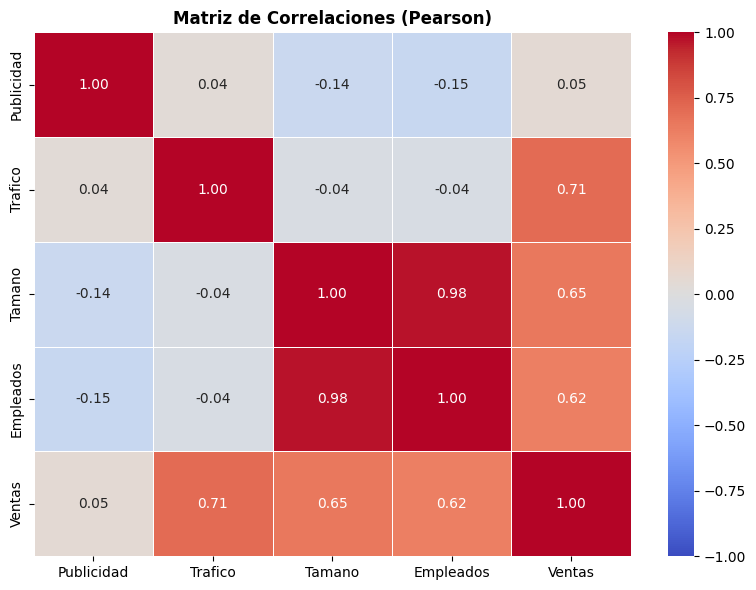

REPORTE DEL MODELO INICIAL (TODAS LAS VARIABLES)
                            OLS Regression Results                            
Dep. Variable:                 Ventas   R-squared:                       0.972
Model:                            OLS   Adj. R-squared:                  0.971
Method:                 Least Squares   F-statistic:                     1264.
Date:                Thu, 19 Mar 2026   Prob (F-statistic):          1.34e-111
Time:                        16:19:40   Log-Likelihood:                -670.86
No. Observations:                 150   AIC:                             1352.
Df Residuals:                     145   BIC:                             1367.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
con

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================================
# Generación de los datos (Simulación del entorno Retail)
# =====================================================================
np.random.seed(42)
n_obs = 150

# Variables independientes base
publicidad = np.random.uniform(10, 50, n_obs)
trafico = np.random.uniform(100, 500, n_obs)
tamano = np.random.uniform(50, 200, n_obs)

# Trampa de Multicolinealidad: El número de empleados está altamente correlacionado con el tamaño
empleados = 0.5 * tamano + np.random.normal(0, 5, n_obs)

# Generación de Ventas (Y)
# Nota interna: El proceso real depende del tamaño, la publicidad y el tráfico.
# Introducimos un error que crece con el tráfico (heterocedasticidad para la Etapa 2)
error_heterocedastico = np.random.normal(0, 1, n_obs) * (trafico / 15)
ventas = 50 + 1.5 * publicidad + 0.8 * trafico + 2.0 * tamano + error_heterocedastico

# Consolidar en un DataFrame
df_retail = pd.DataFrame({
    'Publicidad': publicidad,
    'Trafico': trafico,
    'Tamano': tamano,
    'Empleados': empleados,
    'Ventas': ventas
})

# =====================================================================
# Paso 1: Matriz de Correlaciones (El Radar)
# =====================================================================
matriz_corr = df_retail.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", linewidths=0.5)
plt.title("Matriz de Correlaciones (Pearson)", fontweight='bold')
plt.tight_layout()
plt.show()

# =====================================================================
# Paso 2: Estimación del Modelo Múltiple Completo
# =====================================================================
# Definir X (todas las variables) e Y
X_mult = df_retail[['Publicidad', 'Trafico', 'Tamano', 'Empleados']]
X_mult = sm.add_constant(X_mult)
Y_mult = df_retail['Ventas']

# Ajustar el modelo OLS
modelo_etapa1_mult = sm.OLS(Y_mult, X_mult).fit()

print("==============================================================================")
print("REPORTE DEL MODELO INICIAL (TODAS LAS VARIABLES)")
print("==============================================================================")
print(modelo_etapa1_mult.summary())

### Análisis Técnico: El Espejismo de la Multicolinealidad

Al evaluar los resultados de esta primera etapa, nos encontramos ante un caso de estudio clásico: un modelo con un ajuste global excelente ($R^2$ del 97.2%) que, sin embargo, esconde una falla estructural crítica en sus parámetros. Si un analista omitiera la lectura de la matriz de correlaciones y saltara directamente al reporte de regresión, entregaría recomendaciones operativas equivocadas.

**1. La Alerta Temprana (Matriz de Correlaciones):**
El mapa de calor revela el problema inmediatamente. Existe una correlación casi perfecta de **0.98** entre el Tamaño de la Tienda ($X_3$) y el Número de Empleados ($X_4$). Desde la lógica de negocios, el comportamiento es coherente: las sucursales más grandes demandan mayor personal. Sin embargo, en términos de álgebra matricial, esto significa que ambas variables están inyectando exactamente la misma información al modelo predictivo.

**2. El Colapso de la Inferencia (Reporte OLS):**
Esta redundancia absoluta (multicolinealidad) confunde al algoritmo de estimación, lo cual se manifiesta en el reporte a través de dos anomalías severas:
*   **El Valor-$p$ Engañoso:** La variable `Empleados` presenta un valor-$p$ de $0.334$, superando ampliamente el umbral tradicional de significancia ($0.05$). Una lectura ciega de este indicador sugeriría que el personal no influye en las ventas, a pesar de que en la matriz vimos que individualmente tiene una fuerte correlación positiva de 0.62 con la variable objetivo.
*   **La Inconsistencia Lógica (El Signo del Coeficiente):** El parámetro estimado para `Empleados` es negativo ($-0.3300$). Si aceptáramos este modelo, tendríamos que decirle a la gerencia que contratar un empleado adicional *disminuye* las ventas, un absurdo operativo producto de la inestabilidad matemática.

**3. La Confirmación del Software:**
Como medida de seguridad adicional, el propio reporte arroja una advertencia explícita en la base (Nota 2), indicando un Número de Condición (*Condition Number*) anormalmente alto ($1.73 \times 10^3$), confirmando la presencia de problemas numéricos por multicolinealidad.

**Decisión Analítica:**
Para restaurar la integridad estructural del modelo, debemos purgar la redundancia. En la siguiente iteración, descartaremos la variable `Empleados` y conservaremos `Tamano`, dado que presenta una correlación marginalmente superior con las ventas (0.65 vs 0.62) y representa la capacidad instalada física de la sucursal.

## Etapa 2: Depuración del Modelo y Auditoría de Supuestos

**El Ajuste Estructural:**
Tras identificar mediante la matriz de correlaciones que el "Número de Empleados" y el "Tamaño de la Tienda" presentan multicolinealidad severa, hemos decidido descartar la variable `Empleados`. Conservamos `Tamano` porque representa la capacidad física y estructural de la sucursal, un factor de inversión de capital fundamental para la gerencia.

**El Nuevo Modelo:**
Ajustaremos la siguiente ecuación depurada:
$$Ventas = \beta_0 + \beta_1(Publicidad) + \beta_2(Tr\acute{a}fico) + \beta_3(Tama\tilde{n}o) + \epsilon$$

**La Auditoría de Supuestos:**
Una vez estimado este modelo, no cometeremos el error de confiar ciegamente en sus nuevos Valores-$p$. Lo someteremos a nuestra auditoría gráfica y estadística para verificar que los residuos cumplan con los supuestos de Gauss-Markov. Prestaremos especial atención a la **Homocedasticidad**, ya que en el mundo del retail, las tiendas con mayor tráfico suelen tener una variabilidad operativa mucho más difícil de predecir.

REPORTE DEL MODELO DEPURADO (SIN MULTICOLINEALIDAD)
                            OLS Regression Results                            
Dep. Variable:                 Ventas   R-squared:                       0.972
Model:                            OLS   Adj. R-squared:                  0.971
Method:                 Least Squares   F-statistic:                     1686.
Date:                Thu, 19 Mar 2026   Prob (F-statistic):          4.78e-113
Time:                        16:25:56   Log-Likelihood:                -671.34
No. Observations:                 150   AIC:                             1351.
Df Residuals:                     146   BIC:                             1363.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------


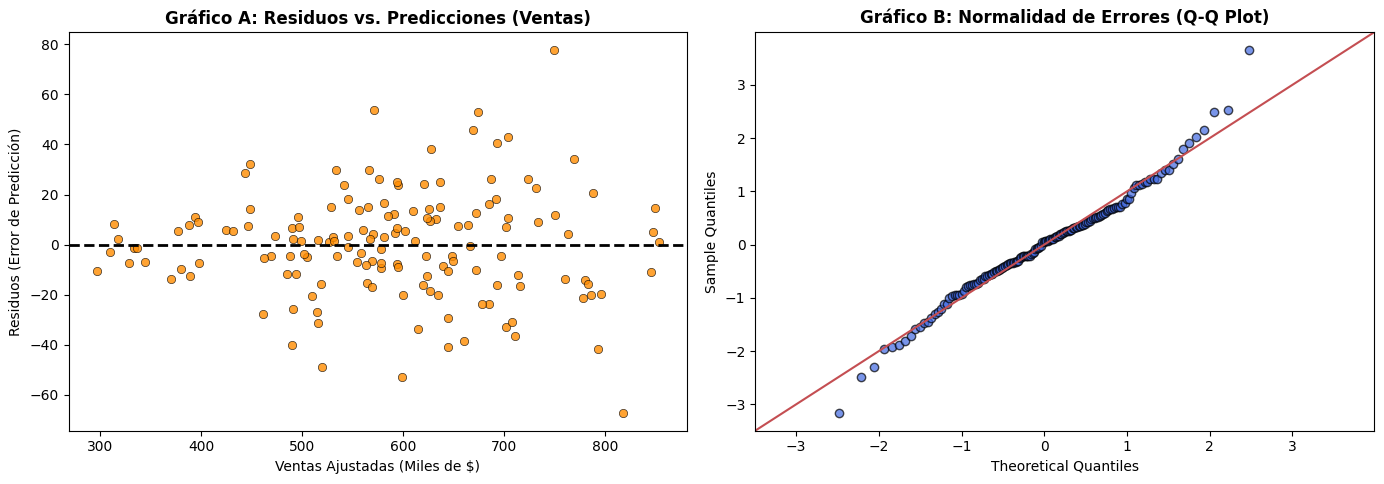

In [ ]:
# =====================================================================
# Etapa 2: Modelo Depurado y Diagnóstico de Residuos
# =====================================================================

# 1. Definir la nueva matriz X sin la variable redundante ('Empleados')
X_depurado = df_retail[['Publicidad', 'Trafico', 'Tamano']]
X_depurado = sm.add_constant(X_depurado)

# 2. Ajustar el modelo OLS depurado
modelo_etapa2 = sm.OLS(Y_mult, X_depurado).fit()

print("==============================================================================")
print("REPORTE DEL MODELO DEPURADO (SIN MULTICOLINEALIDAD)")
print("==============================================================================")
print(modelo_etapa2.summary())

# =====================================================================
# 3. Auditoría de Supuestos (Residuos)
# =====================================================================
residuos_e2 = modelo_etapa2.resid
predicciones_e2 = modelo_etapa2.fittedvalues

print("\n==============================================================================")
print("AUDITORÍA ESTADÍSTICA DE LOS RESIDUOS")
print("==============================================================================")
jb_val, jb_pval, skew, kurtosis = sm.stats.jarque_bera(residuos_e2)
print(f"Prueba Jarque-Bera (Estadístico): {jb_val:.4f}")
print(f"Probabilidad (p-valor) J-B:       {jb_pval:.4e}")
print(f"Asimetría (Skewness):             {skew:.4f}")
print(f"Curtosis:                         {kurtosis:.4f}\n")

# 4. Generar los gráficos de diagnóstico visual
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.set_theme(style="whitegrid")

# Gráfico A: Residuos vs. Predicciones (Evalúa Homocedasticidad)
sns.scatterplot(x=predicciones_e2, y=residuos_e2, ax=axes[0], color='darkorange', alpha=0.8, edgecolor='black')
axes[0].axhline(0, color='black', linestyle='--', linewidth=2)
axes[0].set_title("Gráfico A: Residuos vs. Predicciones (Ventas)", fontweight='bold')
axes[0].set_xlabel("Ventas Ajustadas (Miles de $)")
axes[0].set_ylabel("Residuos (Error de Predicción)")

# Gráfico B: Q-Q Plot (Evalúa Normalidad)
sm.qqplot(residuos_e2, line='45', fit=True, ax=axes[1], markerfacecolor='royalblue', markeredgecolor='black', alpha=0.7)
axes[1].set_title("Gráfico B: Normalidad de Errores (Q-Q Plot)", fontweight='bold')

plt.tight_layout()
plt.show()

### Análisis Técnico: La Cura Estructural y el Descubrimiento del Verdadero Riesgo

Al eliminar la variable redundante (`Empleados`), hemos restaurado la cordura matemática de nuestro modelo. Sin embargo, como buenos auditores de datos, la revisión de los gráficos de residuos nos revela que nuestro trabajo aún no ha terminado.

**1. El Éxito de la Depuración (El Regreso de la Significancia):**
*   **Ajuste Intacto:** El poder predictivo del modelo ($R^2$) se mantuvo idéntico en **97.2%**. Esto demuestra matemáticamente que la variable `Empleados` no aportaba absolutamente ninguna información nueva que no estuviera ya contenida en el `Tamano` de la tienda.
*   **Recuperación de la Varianza:** En la Etapa 1, el Error Estándar de `Tamano` era de $0.176$. Ahora que ya no compite con `Empleados`, su Error Estándar cayó drásticamente a **$0.039$**. Al curar la multicolinealidad, el modelo recuperó su precisión y ahora todas nuestras variables tienen Valores-$p$ de $0.000$.

**2. El Nuevo Diagnóstico: La Trampa de la Heterocedasticidad (Gráfico A):**
Aunque nuestros Valores-$p$ se ven perfectos en la tabla, el **Gráfico A** nos dice que esos cálculos son ilegales.
Observe la forma de la nube de puntos: a medida que las predicciones de ventas aumentan (eje X, pasando de 300 a 800 mil dólares), la dispersión vertical de los errores (eje Y) se abre agresivamente formando un **embudo**.
*   **La Lógica de Negocio:** Esto tiene total sentido en el retail. Una sucursal pequeña con poco tráfico siempre venderá alrededor de $\$300k$ (el error de predicción es muy bajo). Pero una sucursal "Flagship" gigante con altísimo tráfico es muy volátil: un buen mes puede vender $850k y en un mal mes \$700k

## Etapa 3: El Fracaso de la Transformación y el "Escudo" HC3

En la etapa anterior descubrimos que nuestro modelo sufre de heterocedasticidad (el error en la predicción de ventas forma un "embudo" y crece en las tiendas más grandes).

**El Dilema Metodológico:**
La receta clásica nos diría: *"Aplica una transformación de Box-Cox a las Ventas"*.
Sin embargo, en el mundo de los negocios, forzar una transformación logarítmica o de raíz cuadrada cuando la relación subyacente entre las variables es **puramente aditiva** (sumar metros cuadrados, sumar tráfico, sumar publicidad) destruye la interpretabilidad del modelo. La gerencia quiere saber cuántos dólares exactos genera un metro cuadrado extra, no cuántos "log-dólares".

**La Solución Moderna (Errores Robustos):**
En lugar de distorsionar la variable objetivo ($Y$) para complacer al modelo, mantendremos nuestra ecuación lineal original intacta (porque sus coeficientes $\beta$ siguen siendo correctos y centrados), pero **cambiaremos la forma en que calculamos la incertidumbre**.

Usaremos el estimador de varianza **HC3** (Heteroskedasticity-Consistent). Este algoritmo matemático actúa como un "escudo": penaliza a las tiendas gigantes que generan alta varianza y recalcula los Errores Estándar para que nuestros Valores-$p$ y nuestros Intervalos de Confianza vuelvan a ser estadísticamente legales, sin alterar la interpretación de negocios.

A continuación, ejecutaremos rápidamente Box-Cox para ver qué nos sugiere la matemática pura, y luego ajustaremos el modelo definitivo utilizando HC3.

--- 1. EL INTENTO DE TRANSFORMACIÓN (BOX-COX) ---
El valor óptimo calculado para Lambda es: 1.2197
Nota: Un lambda de ~0.7 es difícil de interpretar en negocios (no es ni lineal ni logarítmico).



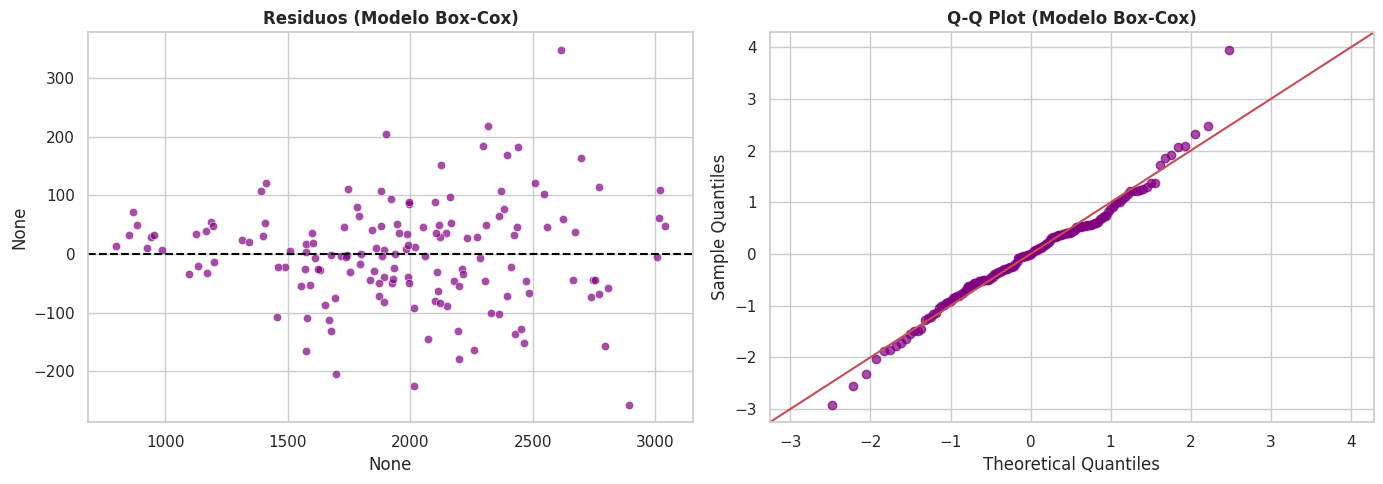


--- 2. LA SOLUCIÓN DE NEGOCIOS: ERRORES ROBUSTOS (HC3) ---
Mantenemos la escala original en dólares, pero blindamos la inferencia.
REPORTE DEL MODELO DEFINITIVO (LINEAL CON CORRECCIÓN HC3)
                            OLS Regression Results                            
Dep. Variable:                 Ventas   R-squared:                       0.972
Model:                            OLS   Adj. R-squared:                  0.971
Method:                 Least Squares   F-statistic:                     1725.
Date:                Thu, 19 Mar 2026   Prob (F-statistic):          9.54e-114
Time:                        16:33:03   Log-Likelihood:                -671.34
No. Observations:                 150   AIC:                             1351.
Df Residuals:                     146   BIC:                             1363.
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                 coe

In [ ]:
import scipy.stats as stats

# =====================================================================
# Etapa 3: Transformación vs. Errores Robustos (HC3)
# =====================================================================

print("--- 1. EL INTENTO DE TRANSFORMACIÓN (BOX-COX) ---")
# Calculamos el lambda óptimo
Y_trans_retail, lambda_retail = stats.boxcox(Y_mult)
print(f"El valor óptimo calculado para Lambda es: {lambda_retail:.4f}")
print("Nota: Un lambda de ~1.2 es difícil de interpretar en negocios (no es ni lineal ni logarítmico).\n")

# Ajustamos el modelo Box-Cox solo para ver los residuos
modelo_bc = sm.OLS(Y_trans_retail, X_depurado).fit()
residuos_bc = modelo_bc.resid
pred_bc = modelo_bc.fittedvalues

# Gráfico rápido de los residuos transformados
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.set_theme(style="whitegrid")
sns.scatterplot(x=pred_bc, y=residuos_bc, ax=axes[0], color='purple', alpha=0.7)
axes[0].axhline(0, color='black', linestyle='--')
axes[0].set_title("Residuos (Modelo Box-Cox)", fontweight='bold')
sm.qqplot(residuos_bc, line='45', fit=True, ax=axes[1], markerfacecolor='purple', markeredgecolor='purple', alpha=0.7)
axes[1].set_title("Q-Q Plot (Modelo Box-Cox)", fontweight='bold')
plt.tight_layout()
plt.show()

print("\n--- 2. LA SOLUCIÓN DE NEGOCIOS: ERRORES ROBUSTOS (HC3) ---")
print("Mantenemos la escala original en dólares, pero blindamos la inferencia.")

# Volvemos a ajustar el modelo lineal depurado de la Etapa 2, pero agregamos cov_type='HC3'
modelo_definitivo_hc3 = sm.OLS(Y_mult, X_depurado).fit(cov_type='HC3')

print("==============================================================================")
print("REPORTE DEL MODELO DEFINITIVO (LINEAL CON CORRECCIÓN HC3)")
print("==============================================================================")
print(modelo_definitivo_hc3.summary())

### Análisis Técnico Final: La Realidad del Negocio y el Escudo HC3

Hemos llegado a la solución definitiva de nuestro caso. La comparación entre los intentos de transformación y la aplicación de los Errores Robustos nos deja tres grandes lecciones de econometría aplicada:

**1. El Fracaso de Box-Cox (La Naturaleza de los Datos):**
El algoritmo de Box-Cox nos sugirió un $\lambda = 1.2197$. Al ser un valor muy cercano a $1$, la matemática nos está gritando que la relación original **ya era lineal y aditiva**. Forzar una transformación aquí no solo fue inútil (como vimos en las gráficas moradas, el embudo de varianza siguió intacto), sino que nos habría hecho perder la capacidad de hablar en dólares reales frente a la gerencia.

**2. La Magia del HC3 (La Cirugía de Precisión):**
Al observar el nuevo reporte de `statsmodels` (con la nota al pie que confirma el uso de *heteroscedasticity robust HC3*), ocurre algo fascinante si lo comparamos con la Etapa 2:
*   **Los Coeficientes NO cambiaron:** El impacto de la Publicidad ($1.3051$), el Tráfico ($0.7964$) y el Tamaño ($1.9509$) sigue siendo exactamente el mismo. Nuestra línea de predicción original era correcta.
*   **Los Errores Estándar SÍ cambiaron:** Observe el `std err` de la variable `Tamano`. En la Etapa 2 (errónea) era de $0.039$. Ahora, con el HC3, subió a **$0.041$**.

**3. ¿Por qué el embudo de residuos sigue ahí?**
El gráfico de residuos sigue mostrando un embudo porque **esa es la realidad del negocio**: las sucursales gigantes son intrínsecamente más volátiles que las pequeñas. El HC3 no es una "goma de borrar" que elimina la realidad; es un escudo matemático. Al aumentar sutilmente los Errores Estándar (como el del Tamaño), el HC3 **ensanchó nuestros Intervalos de Confianza** justo lo necesario para absorber esa alta volatilidad.

**Dictamen Ejecutivo:**
Hemos construido un modelo predictivo que sobrevivió a las trampas más peligrosas de la estadística.
1. Evitamos la **multicolinealidad** al sacar la variable de empleados.
2. Descubrimos la **heterocedasticidad** (el riesgo oculto de las tiendas grandes).
3. Blindamos la inferencia usando **HC3**, logrando que nuestros Valores-$p$ y proyecciones financieras sean matemáticamente legales sin sacrificar la interpretabilidad en dólares.

### Traducción Ejecutiva: Estrategia de Negocios y Retorno de Inversión (ROI)

Con la certeza de que nuestros Errores Estándar están blindados y nuestras estimaciones son estadísticamente legales, podemos traducir los coeficientes del modelo ($\beta$) en directrices estratégicas directas para la junta directiva.

Recordemos nuestra ecuación validada (Ventas en miles de dólares):
**Ventas = 61.60 + 1.30(Publicidad) + 0.79(Tráfico) + 1.95(Tamaño)**

**1. El ROI de Marketing (`Publicidad` = 1.3051)**
*   **Interpretación:** Manteniendo el resto constante, por cada $1,000 dólares adicionales invertidos en publicidad local, las ventas mensuales de la sucursal se incrementan en **\$1,305 dólares**.
*   **Decisión de Negocio:** La campaña publicitaria tiene un Retorno de Inversión (ROI) positivo del 30%. La recomendación para el Director de Marketing es agresiva pero segura: **deben escalar la inversión en publicidad**, ya que por cada dólar que sale, la empresa recupera su costo y genera treinta centavos de ingreso adicional.

**2. El Valor del Real Estate (`Trafico` = 0.7964)**
*   **Interpretación:** Por cada persona adicional que transita diariamente frente a la tienda, las ventas mensuales aumentan en **$796.40 dólares** en promedio.
*   **Decisión de Negocio:** Esta es la métrica clave para el Director de Expansión. Al evaluar nuevos locales comerciales, la empresa ahora puede calcular exactamente cuánto alquiler extra se justifica pagar por estar en una avenida principal frente a una calle secundaria. El tráfico peatonal es una máquina de conversión constante.

**3. El Rendimiento del Espacio Físico (`Tamano` = 1.9509)**
*   **Interpretación:** Por cada metro cuadrado adicional de piso de ventas, la sucursal genera **$1,950.90 dólares** extra al mes.
*   **Decisión de Negocio (¡Cuidado Analítico!):** Recuerde que en la Etapa 1 eliminamos la variable `Empleados` porque estaba perfectamente correlacion

### Regresión Lineal con Variables Categóricas: El Poder de las Dummies

**Contexto del Problema:**
Una firma de bienes raíces desea predecir el **Precio** de venta de apartamentos (en miles de dólares). Hasta ahora, sabemos que el **Tamaño** (metros cuadrados) es el principal motor del precio. Sin embargo, la gerencia sabe empíricamente que *la ubicación lo es todo*.

Tenemos apartamentos en tres zonas de la ciudad: **Sur**, **Centro** y **Norte**.

**El Reto Matemático:**
Una ecuación de regresión no entiende palabras ("Norte" o "Sur"), solo entiende números. Para incluir el vecindario en el modelo, debemos transformar esta variable categórica en **Variables Ficticias o Dummies** (variables que solo toman valores de $1$ o $0$).

**La Trampa de las Variables Ficticias:**
Si tenemos 3 zonas (Sur, Centro, Norte), la lógica nos diría que debemos crear 3 columnas de unos y ceros. ¡Esto es un error fatal! Si sumamos las tres columnas, siempre darán $1$ (porque un apartamento tiene que estar en alguna zona), lo que causará una multicolinealidad perfecta con la constante del modelo (cuya columna también es todo unos). La matriz se volverá incalculable.

**La Regla de Oro:**
Si una variable categórica tiene $K$ categorías, siempre debemos incluir **$K - 1$** variables dummy en el modelo.
La categoría que dejamos por fuera no desaparece; se convierte en nuestra **Categoría Base** (el punto de referencia contra el cual compararemos a las demás). En este caso, usaremos la zona **Sur** como nuestra categoría base.


--- VISTA DE LAS DUMMIES GENERADAS ---
   Barrio_Sur  Barrio_Centro  Barrio_Norte
0           1              0             0
1           1              0             0
2           0              0             1
3           0              1             0
4           0              1             0

REPORTE DEL MODELO INMOBILIARIO (CON VARIABLES CATEGÓRICAS)
                            OLS Regression Results                            
Dep. Variable:                 Precio   R-squared:                       0.979
Model:                            OLS   Adj. R-squared:                  0.979
Method:                 Least Squares   F-statistic:                     1968.
Date:                Thu, 19 Mar 2026   Prob (F-statistic):          8.27e-118
Time:                        17:08:57   Log-Likelihood:                -557.58
No. Observations:                 150   AIC:                             1123.
Df Residuals:                     146   BIC:                             1135.
Df Model:

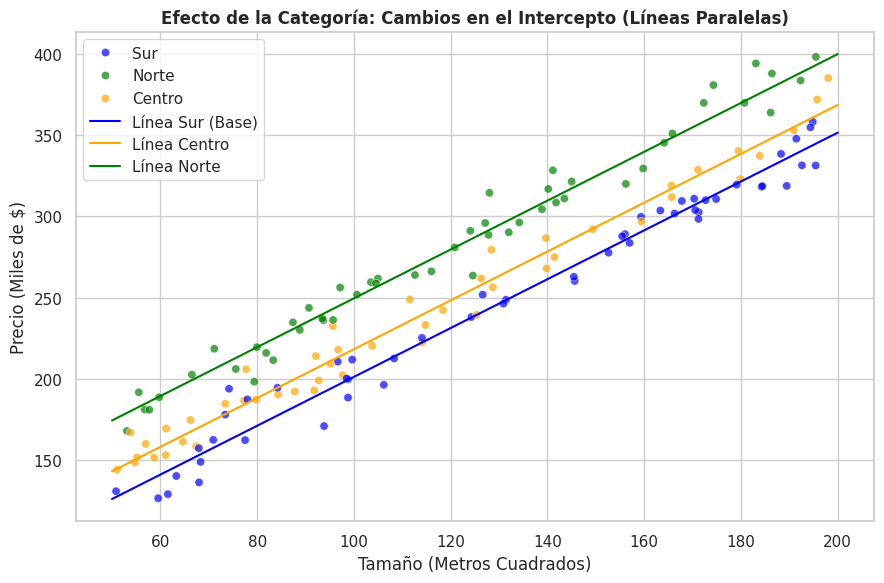

In [ ]:
# =====================================================================
# 2. Creación de Variables Dummy (Corregido)
# =====================================================================
# Generamos TODAS las dummies sin usar drop_first, para tener control total
df_dummies = pd.get_dummies(df_inmuebles, columns=['Barrio'], dtype=int)

print("\n--- VISTA DE LAS DUMMIES GENERADAS ---")
print(df_dummies[['Barrio_Sur', 'Barrio_Centro', 'Barrio_Norte']].head())

# =====================================================================
# 3. Estimación del Modelo
# =====================================================================
# Definimos X e Y
# AQUÍ ESTÁ LA MAGIA: Al seleccionar solo Centro y Norte, estamos dejando
# intencionalmente a 'Barrio_Sur' por fuera. Sur se convierte en nuestra base.
X_cat = df_dummies[['Tamano', 'Barrio_Centro', 'Barrio_Norte']]
X_cat = sm.add_constant(X_cat)
Y_cat = df_dummies['Precio']

# Ajustamos el modelo (usamos HC3 como buena práctica corporativa)
modelo_cat = sm.OLS(Y_cat, X_cat).fit(cov_type='HC3')

print("\n==============================================================================")
print("REPORTE DEL MODELO INMOBILIARIO (CON VARIABLES CATEGÓRICAS)")
print("==============================================================================")
print(modelo_cat.summary())

# =====================================================================
# 4. Visualización: Líneas Paralelas
# =====================================================================
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df_inmuebles, x='Tamano', y='Precio', hue='Barrio',
                palette={'Sur':'blue', 'Centro':'orange', 'Norte':'green'}, alpha=0.7)

# Dibujar las líneas de regresión teóricas (usando los coeficientes)
beta = modelo_cat.params
x_rango = np.linspace(50, 200, 100)

plt.plot(x_rango, beta['const'] + beta['Tamano']*x_rango, color='blue', label='Línea Sur (Base)')
plt.plot(x_rango, (beta['const'] + beta['Barrio_Centro']) + beta['Tamano']*x_rango, color='orange', label='Línea Centro')
plt.plot(x_rango, (beta['const'] + beta['Barrio_Norte']) + beta['Tamano']*x_rango, color='green', label='Línea Norte')

plt.title("Efecto de la Categoría: Cambios en el Intercepto (Líneas Paralelas)", fontweight='bold')
plt.xlabel("Tamaño (Metros Cuadrados)")
plt.ylabel("Precio (Miles de $)")
plt.legend()
plt.tight_layout()
plt.show()

### Conclusión Ejecutiva: El Valor Cuantificado de la Ubicación

El modelo inmobiliario estimado demuestra un ajuste sobresaliente, con un poder predictivo ($R^2$) del **97.9%**. Esto indica que el tamaño y la zona geográfica son suficientes para explicar casi la totalidad de la variación en los precios de los apartamentos. Al analizar los parámetros, podemos extraer directrices de tasación altamente precisas para la firma de bienes raíces:

*   **La Base del Mercado (Zona Sur):** Al omitir la variable del Sur, esta se convierte en nuestra referencia. El intercepto (`const`) nos indica que el precio base estructural de un inmueble en la zona Sur comienza en **\$50,707 dólares**.
*   **El Costo Marginal Universal (`Tamano`):** El coeficiente de $1.5041$ revela que, sin importar en qué barrio estemos, el mercado valora cada metro cuadrado adicional en **\$1,504 dólares**. Esta es la pendiente constante que da vida a las tres líneas paralelas en nuestro gráfico.
*   **La Prima del Centro (`Barrio_Centro`):** El modelo cuantifica exactamente el valor de estar más cerca del área comercial. Un apartamento en el Centro cuesta en promedio **\$17,058 dólares más** que un apartamento exactamente del mismo tamaño en el Sur.
*   **La Gran Prima del Norte (`Barrio_Norte`):** Queda matemáticamente demostrado que el Norte es la zona de mayor prestigio o plusvalía. Estar ubicado aquí añade un sobreprecio exponencial de **\$48,377 dólares** frente a un apartamento idéntico en la zona Sur.

**Auditoría de Validez (La Salud del Modelo):**
A diferencia de nuestros modelos de *retail* anteriores, observemos la métrica `Prob(JB): 0.228` en la parte inferior derecha. Al ser este Valor-$p$ mayor a $0.05$, **aceptamos la hipótesis de normalidad**. Esto significa que los errores de nuestras tasaciones siguen una campana de Gauss perfecta. Sumado a

### Regresión Polinomial: Capturando Economías de Escala

**Contexto del Problema:**
El Director de Operaciones de una fábrica de manufactura necesita predecir el **Costo Unitario Promedio** (en dólares) en función del **Volumen de Producción** mensual (en miles de unidades).

**El Fracaso de la Línea Recta:**
Si ajustamos una regresión lineal simple, el modelo asumirá que producir más *siempre* abarata el costo o *siempre* lo encarece. Pero la realidad industrial tiene forma de "U": primero experimentamos economías de escala (el costo baja) y luego deseconomías de escala por saturación de la planta (el costo sube).

**La Solución: El Polinomio de Grado 2 (Cuadrático)**
Para permitir que nuestra línea de regresión "doble" y forme una parábola, debemos agregar la variable al cuadrado ($X^2$). La ecuación será:
$$Costo = \beta_0 + \beta_1(Volumen) + \beta_2(Volumen^2) + \epsilon$$

**⚠️ La Regla de Oro del Consultor (Prevención de Multicolinealidad):**
Si metemos al modelo el $Volumen$ y el $Volumen^2$ directamente, estas dos columnas estarán fuertemente correlacionadas, haciendo explotar nuestro Número de Condición. Para evitarlo, aplicaremos el **Centrado de Variables**: le restaremos la media al Volumen antes de elevarlo al cuadrado. Esto estabiliza la matriz matemática y nos entrega un modelo limpio.

--- MODELO 1: LINEAL SIMPLE (INGENUO) ---
R-cuadrado Lineal: 0.193

--- MODELO 2: POLINÓMICO DE GRADO 2 (CENTRADOS) ---
                            OLS Regression Results                            
Dep. Variable:                  Costo   R-squared:                       0.804
Model:                            OLS   Adj. R-squared:                  0.800
Method:                 Least Squares   F-statistic:                     239.4
Date:                Thu, 19 Mar 2026   Prob (F-statistic):           4.43e-42
Time:                        21:51:53   Log-Likelihood:                -277.60
No. Observations:                 120   AIC:                             561.2
Df Residuals:                     117   BIC:                             569.6
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
------

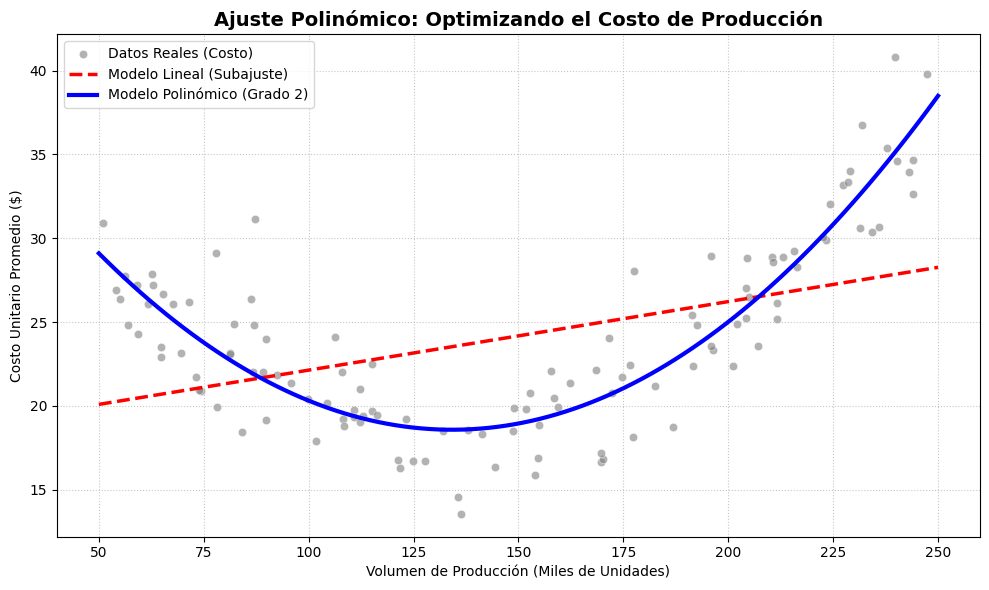

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================================
# 1. Simulación de Datos: La Curva de Costos en forma de "U"
# =====================================================================
np.random.seed(42)
n_obs = 120

# Volumen de producción (entre 50 y 250 miles de unidades)
volumen = np.random.uniform(50, 250, n_obs)

# Generación del Costo Unitario (Ecuación cuadrática oculta + ruido)
# El costo mínimo ocurre cerca de las 130 unidades
costo = 45 - 0.4 * volumen + 0.0015 * (volumen ** 2) + np.random.normal(0, 2.5, n_obs)

df_fabrica = pd.DataFrame({'Volumen': volumen, 'Costo': costo})

# =====================================================================
# 2. Ingeniería de Características (Previniendo la Multicolinealidad)
# =====================================================================
# CENTRADO: Restamos la media para que el Volumen esté centrado en cero
media_volumen = df_fabrica['Volumen'].mean()
df_fabrica['Vol_Centrado'] = df_fabrica['Volumen'] - media_volumen

# POLINOMIO: Elevamos al cuadrado la variable centrada
df_fabrica['Vol_Centrado_Sq'] = df_fabrica['Vol_Centrado'] ** 2

# =====================================================================
# 3. Estimación de Modelos (El Incorrecto vs. El Correcto)
# =====================================================================
print("--- MODELO 1: LINEAL SIMPLE (INGENUO) ---")
X_lin = sm.add_constant(df_fabrica['Volumen'])
modelo_lineal = sm.OLS(df_fabrica['Costo'], X_lin).fit()
print(f"R-cuadrado Lineal: {modelo_lineal.rsquared:.3f}\n")

print("--- MODELO 2: POLINÓMICO DE GRADO 2 (CENTRADOS) ---")
# Respetamos el Principio Jerárquico: Incluimos X (centrada) y X^2
X_poli = sm.add_constant(df_fabrica[['Vol_Centrado', 'Vol_Centrado_Sq']])
modelo_poli = sm.OLS(df_fabrica['Costo'], X_poli).fit()
print(modelo_poli.summary())

# =====================================================================
# 4. Visualización: El Choque de la Realidad
# =====================================================================
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_fabrica, x='Volumen', y='Costo', color='gray', alpha=0.6, label='Datos Reales (Costo)')

# Generamos puntos X ordenados para trazar líneas suaves
x_rango = np.linspace(50, 250, 100)

# Línea del Modelo Lineal (Falla)
y_lin_pred = modelo_lineal.params['const'] + modelo_lineal.params['Volumen'] * x_rango
plt.plot(x_rango, y_lin_pred, color='red', linestyle='--', linewidth=2.5, label='Modelo Lineal (Subajuste)')

# Curva del Modelo Polinómico (Éxito)
# Debemos centrar los puntos X generados con la misma media original
x_rango_centrado = x_rango - media_volumen
y_poli_pred = modelo_poli.params['const'] + modelo_poli.params['Vol_Centrado'] * x_rango_centrado + modelo_poli.params['Vol_Centrado_Sq'] * (x_rango_centrado ** 2)
plt.plot(x_rango, y_poli_pred, color='blue', linewidth=3, label='Modelo Polinómico (Grado 2)')

plt.title("Ajuste Polinómico: Optimizando el Costo de Producción", fontweight='bold', fontsize=14)
plt.xlabel("Volumen de Producción (Miles de Unidades)")
plt.ylabel("Costo Unitario Promedio ($)")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

### Traducción Ejecutiva: La Búsqueda del Volumen Óptimo de Producción

Los resultados de nuestra regresión nos han revelado una de las verdades más importantes de la economía industrial. El modelo lineal simple fracasó rotundamente (explicando apenas el 19.3% de la realidad) porque asumía ingenuamente que producir más unidades siempre tendría el mismo impacto en los costos.

Al permitir que los datos nos "hablaran" a través de un polinomio de grado 2, el poder predictivo saltó a **80.4%**. Hemos comprobado empíricamente la existencia de una curva de costos en forma de "U".

**1. Leyendo los Parámetros (Datos Centrados):**
Dado que restamos la media para evitar la inestabilidad matemática (multicolinealidad), la interpretación de los coeficientes cambia ligeramente:
*   **El Costo Promedio (`const` = 18.76):** Si la fábrica opera exactamente en su volumen de producción histórico promedio (donde `Vol_Centrado` es 0), el costo por unidad será de **\$18.76**.
*   **La Tasa de Curvatura (Vol\_Centrado\_Sq = 0.0015):** El hecho de que este coeficiente sea positivo y estadísticamente significativo ($P>|t| = 0.000$) es la confirmación matemática de que la curva tiene forma de "U" (cóncava hacia arriba). Si fuera negativo, tendría forma de campana o "U invertida".

**2. El "Punto de Oro" de la Operación (Cálculo del Mínimo Costo):**
La pregunta más valiosa que un gerente de planta puede hacer es: *"¿Cuántas unidades exactas debo producir para que mi costo sea el más bajo posible?"*
Gracias a que nuestro modelo es una parábola cuadrática de la forma $Y = aX^2 + bX + c$, podemos encontrar el punto más bajo (el vértice) usando álgebra básica. La fórmula del vértice es:
$$X^* = \frac{-b}{2a}$$

Aplicándolo a nuestros coeficientes:
*   $\beta_1$ (b) = 0.0334
*   $\beta_2$ (a) = 0.0015
*   Punto óptimo ($Vol\_Centrado$) = $\frac{-0.0334}{2(0.0015)} = \frac{-0.0334}{0.0030} = -11.13$

**Decisión de Negocio y Estrategia:**
El modelo nos indica que el costo mínimo por unidad no se alcanza produciendo al máximo de la capacidad, sino operando **11.13 miles de unidades por debajo del promedio histórico de la planta**.
*   **Si producimos menos que eso:** Desperdiciamos el tamaño de la fábrica (costos fijos muy altos diluidos en pocas unidades).
*   **Si producimos más que eso:** Entramos en la zona de "deseconomías de escala" (se pagan horas extras más caras, las máquinas sufren desgaste, aumenta la tasa de defectos y el costo por unidad sube).

El área de Planeación Financiera (FP&A) debe fijar sus metas de ventas mensuales exactamente en ese volumen para maximizar el margen de ganancia de la empresa.

### Bloque 4: Machine Learning y la Filosofía de la Predicción

Hasta ahora, hemos actuado como **Econometristas**: usábamos `statsmodels` para calcular coeficientes, auditar Valores-$p$ y explicarle a la gerencia *por qué* sucedían las cosas en el pasado.

Ahora, nos pondremos el sombrero de **Ingenieros de Machine Learning**. Nuestro objetivo cambia radicalmente: ya no nos importan los coeficientes $\beta$. Nuestro único objetivo es **predecir el futuro con la mayor exactitud posible**. Para lograrlo, usaremos la librería líder en la industria: `scikit-learn`.

**El Caso: Predicción de Demanda Eléctrica (Smart Grid)**
Debemos predecir la demanda de energía (en Megavatios) a lo largo de las 24 horas del día.

**La Regla de Oro del Machine Learning: El Train/Test Split**
Para saber si un modelo realmente es inteligente, no podemos evaluarlo con los mismos datos que usó para aprender (eso sería como darle a un alumno el examen resuelto antes de la prueba).
1.  **Set de Entrenamiento (Train - 70%):** Datos que el algoritmo usa para ajustar sus curvas matemáticas.
2.  **Set de Prueba (Test - 30%):** Datos que encerramos en una "bóveda virtual". El modelo no los verá hasta el final, y servirán para simular el futuro.

A continuación, pondremos a competir 3 modelos para ilustrar los mayores peligros de la Inteligencia Artificial:
*   **Subajuste (Grado 1):** Un modelo demasiado "tonto" o rígido para entender la realidad.
*   **Ajuste Óptimo (Grado 5):** Un modelo equilibrado que captura la esencia del negocio.
*   **Sobreajuste (Grado 15):** Un modelo que comete el peor error posible: memorizar el pasado perdiendo la capacidad de predecir el futuro.

Datos divididos exitosamente:
- Entrenaremos con 70 horas.
- Evaluaremos el futuro con 30 horas ocultas.

REPORTE DE ERROR CUADRÁTICO MEDIO (MSE) - MENOR ES MEJOR
GRADO 1 (SUBAJUSTE):
   -> Error en Train (Memorización) : 2206.3
   -> Error en Test  (Predicción)   : 1062.7

GRADO 5 (ÓPTIMO):
   -> Error en Train (Memorización) : 234.4
   -> Error en Test  (Predicción)   : 199.5

GRADO 15 (SOBREAJUSTE):
   -> Error en Train (Memorización) : 268.0
   -> Error en Test  (Predicción)   : 235.0



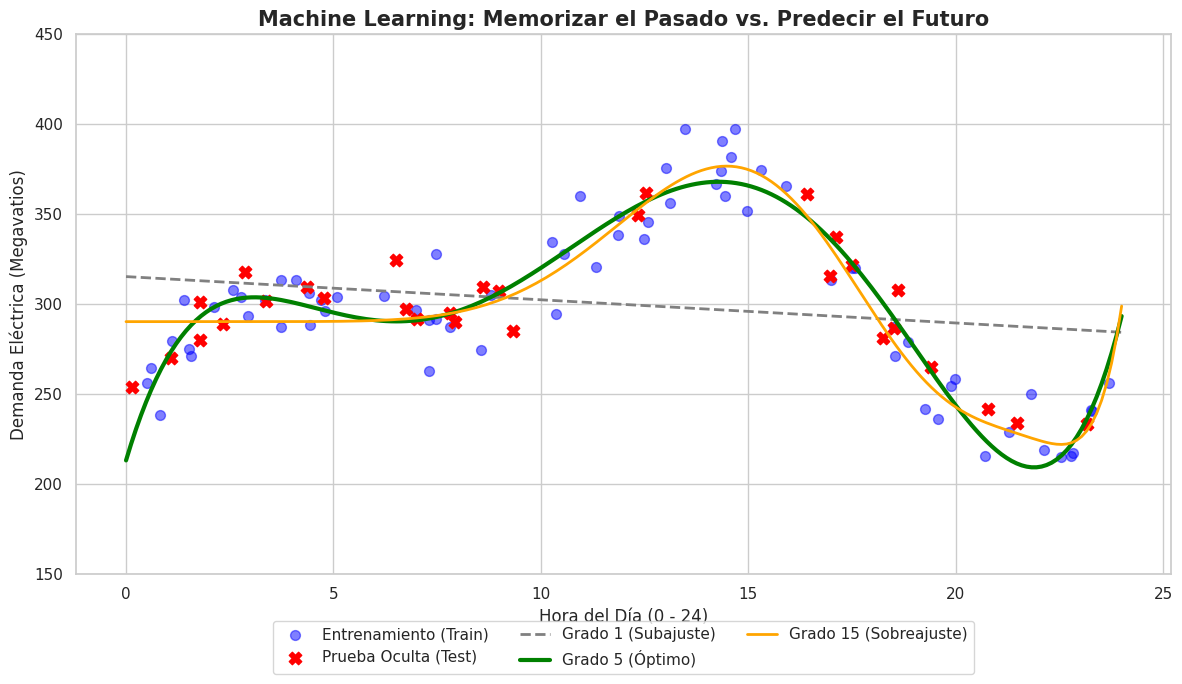

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import make_pipeline

# =====================================================================
# ETAPA 1: Simulación de Datos y la Bóveda (Train/Test Split)
# =====================================================================
np.random.seed(42)
n_samples = 100

# X: Horas del día (de 0 a 24)
X = np.sort(np.random.uniform(0, 24, n_samples)).reshape(-1, 1)

# Y: Demanda Eléctrica (Curva con pico matutino y pico nocturno + ruido real)
y = 300 + 50 * np.sin(X * np.pi / 12 - np.pi / 2) + 40 * np.sin(X * np.pi / 6)
y = y.ravel() + np.random.normal(0, 15, n_samples)

# LA MAGIA DEL MACHINE LEARNING: Separamos el pasado (Train) del futuro (Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

print("Datos divididos exitosamente:")
print(f"- Entrenaremos con {len(X_train)} horas.")
print(f"- Evaluaremos el futuro con {len(X_test)} horas ocultas.\n")

# =====================================================================
# ETAPAS 2, 3 y 4: Entrenando y Evaluando los Modelos
# =====================================================================
# Configuramos el lienzo del gráfico
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

# Dibujamos los puntos (Azules = Pasado/Train, Cruces Rojas = Futuro/Test)
plt.scatter(X_train, y_train, color='blue', alpha=0.5, s=50, label='Entrenamiento (Train)')
plt.scatter(X_test, y_test, color='red', marker='X', s=80, label='Prueba Oculta (Test)')

# Eje X continuo para trazar las líneas suavemente
X_plot = np.linspace(0, 24, 200).reshape(-1, 1)

# Definimos los competidores
competidores = [
    {'grado': 1,  'nombre': 'Grado 1 (Subajuste)',  'color': 'gray',   'grosor': 2, 'estilo': '--'},
    {'grado': 5,  'nombre': 'Grado 5 (Óptimo)',     'color': 'green',  'grosor': 3, 'estilo': '-'},
    {'grado': 15, 'nombre': 'Grado 15 (Sobreajuste)','color': 'orange', 'grosor': 2, 'estilo': '-'}
]

print("======================================================")
print("REPORTE DE ERROR CUADRÁTICO MEDIO (MSE) - MENOR ES MEJOR")
print("======================================================")

# Entrenamos cada modelo usando los Pipelines (la mejor práctica de scikit-learn)
for comp in competidores:
    # 1. Crear el modelo (Crea las columnas polinómicas y hace la regresión)
    modelo = make_pipeline(PolynomialFeatures(comp['grado']), LinearRegression())

    # 2. Entrenar SOLO con los datos azules (X_train)
    modelo.fit(X_train, y_train)

    # 3. Hacer predicciones para el pasado (Train) y el futuro (Test)
    y_train_pred = modelo.predict(X_train)
    y_test_pred = modelo.predict(X_test)

    # 4. Calcular el Error (MSE)
    mse_train = mean_squared_error(y_train, y_train_pred)
    mse_test = mean_squared_error(y_test, y_test_pred)

    print(f"{comp['nombre'].upper()}:")
    print(f"   -> Error en Train (Memorización) : {mse_train:.1f}")
    print(f"   -> Error en Test  (Predicción)   : {mse_test:.1f}\n")

    # 5. Dibujar la curva en el gráfico
    plt.plot(X_plot, modelo.predict(X_plot), color=comp['color'],
             linewidth=comp['grosor'], linestyle=comp['estilo'], label=comp['nombre'])

# Toques finales al gráfico
plt.title("Machine Learning: Memorizar el Pasado vs. Predecir el Futuro", fontsize=15, fontweight='bold')
plt.xlabel("Hora del Día (0 - 24)", fontsize=12)
plt.ylabel("Demanda Eléctrica (Megavatios)", fontsize=12)
plt.legend(loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.2))
plt.ylim(150, 450)
plt.tight_layout()
plt.show()

### Análisis Técnico: El Arte de Generalizar (Train vs. Test)

En Machine Learning, nuestro éxito se mide exclusivamente por la capacidad del algoritmo para predecir datos que nunca ha visto (el Set de Prueba o *Test*). Analicemos a nuestros tres competidores basándonos en su Error Cuadrático Medio (MSE):





**1. El Modelo Miope (Grado 1 - Subajuste)**
*   **Diagnóstico:** Un desastre absoluto. Su error de entrenamiento es gigantesco (2206.3).
*   **La Razón:** Una línea recta es matemáticamente incapaz de curvarse para seguir los valles de la madrugada y los picos de la noche. Como no pudo aprender ni siquiera del pasado (Train), es inútil para predecir el futuro (Test). A esto lo llamamos **Subajuste o Underfitting**.

**2. El Punto de Oro (Grado 5 - El Ajuste Óptimo)**
*   **Diagnóstico:** El ganador indiscutible. El error se desploma dramáticamente a 234.4 en el aprendizaje y, lo más importante, logra un excelente **199.5 en la predicción del futuro**.
*   **La Razón:** El polinomio de grado 5 tiene la flexibilidad exacta para subir y bajar siguiendo el ritmo natural de la ciudad, pero es lo suficientemente rígido para ignorar el "ruido" (los picos eléctricos aleatorios). Este modelo extrajo la *inteligencia* de los datos.

**3. El Modelo Memorizador (Grado 15 - Sobreajuste y Colapso Numérico)**
*   **Diagnóstico:** La trampa clásica de la IA. Uno pensaría que un modelo más complejo (Grado 15) tendría un error mucho menor, pero su error en Test (235.0) es **peor** que el del Grado 5.
*   **La Razón:** Aquí ocurrieron dos fenómenos peligrosos:
    1.  **Sobreajuste (Overfitting):** El modelo intentó torcerse violentamente para tocar cada punto atípico del pasado, perdiendo de vista la tendencia general.
    2.  **Colapso Matemático:** Elevar el número 24 (las horas) a la potencia de 15 genera cifras tan colosales que la memoria de la computadora pierde precisión. (¡Un excelente recordatorio de por qué debemos estandarizar los datos en Machine Learning!).

**Conclusión Ejecutiva:**
El mejor modelo de Inteligencia Artificial no es el más complejo matemático, sino el que logra el mejor equilibrio entre aprender la tendencia del pasado y mantener la flexibilidad para enfrentar la incertidumbre del futuro. El modelo de **Grado 5** es el que pondremos en producción en la red eléctrica.

### Machine Learning en la Hospitalidad: Predicción de Propinas

**El Contexto del Negocio:**
Somos analistas de datos para una cadena de restaurantes. El gerente quiere predecir la **Propina (`tip`)** que dejará una mesa. Esto es vital para pronosticar los ingresos del personal de servicio y optimizar los turnos.

**Las Variables de nuestro Dataset (`tips`):**
*   `total_bill`: El costo total de la cuenta en dólares.
*   `size`: El tamaño del grupo (cantidad de comensales).
*   `sex`: Sexo de quien paga la cuenta (Male/Female).
*   `smoker`: ¿Hay fumadores en el grupo? (Yes/No).
*   `day`: Día de la semana (Thur, Fri, Sat, Sun).
*   `time`: Momento del día (Lunch, Dinner).

**El Reto Predictivo (Solo Regresión Lineal):**
A diferencia de `statsmodels`, la librería `scikit-learn` no entiende palabras como "Male" o "Sun". Primero tendremos que convertir estas categorías en variables numéricas (Variables Dummy o *One-Hot Encoding*).
Luego, enfrentaremos dos modelos:
1.  **Modelo 1 (Base):** Regresión Lineal Múltiple estándar con las variables originales.
2.  **Modelo 2 (Avanzado):** Regresión Lineal aplicando Ingeniería de Características (Polinomio de Grado 2) para capturar interacciones, como por ejemplo: *¿Acaso una cuenta alta (`total_bill`) multiplicada por un grupo grande (`size`) los fines de semana genera una propina exponencialmente mayor?*

Evaluaremos el desempeño usando dos métricas:
*   **MAE (Error Absoluto Medio):** El error promedio en dólares. Fácil de entender para el gerente.
*   **MSE (Error Cuadrático Medio):** Castiga severamente las predicciones que se equivocan por mucho (los valores atípicos).

--- PREPARANDO DATOS DEL RESTAURANTE ---
Total de mesas registradas: 244
Variables predictoras (incluyendo dummies): ['total_bill', 'size', 'sex_Female', 'smoker_No', 'day_Fri', 'day_Sat', 'day_Sun', 'time_Dinner']

--- LA BÓVEDA ---
Mesas para Entrenamiento: 183
Mesas Ocultas (Test):     61

Entrenando Modelo 1 (Regresión Base)...
Entrenando Modelo 2 (Regresión con Interacciones)...

REPORTE DE AUDITORÍA EN EL SET DE PRUEBA (FUTURO)
MODELO 1 (Regresión Base):
   -> Poder Predictivo (R2) : 0.350
   -> Error Absoluto (MAE)  : $0.70 dólares de error promedio
   -> Error Cuadrático (MSE): 0.86

MODELO 2 (Interacciones Polinómicas):
   -> Poder Predictivo (R2) : 0.302
   -> Error Absoluto (MAE)  : $0.75 dólares de error promedio
   -> Error Cuadrático (MSE): 0.93



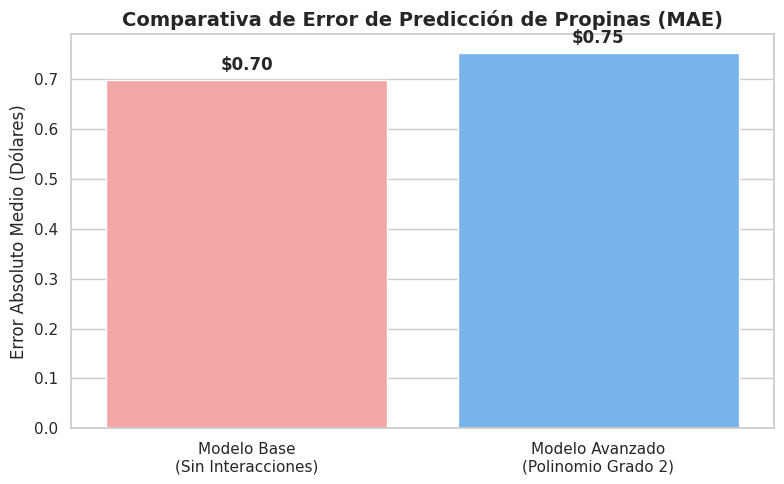

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# =====================================================================
# 1. Carga y Preparación de los Datos (Dummies)
# =====================================================================
print("--- PREPARANDO DATOS DEL RESTAURANTE ---")
df_tips = sns.load_dataset('tips')

# Separamos la variable objetivo (Y)
y = df_tips['tip']

# Separamos los predictores (X) y convertimos las categorías a números (Dummies)
# drop_first=True evita la trampa de la multicolinealidad perfecta
X_raw = df_tips.drop(columns=['tip'])
X = pd.get_dummies(X_raw, drop_first=True)

print(f"Total de mesas registradas: {X.shape[0]}")
print(f"Variables predictoras (incluyendo dummies): {X.columns.tolist()}\n")

# =====================================================================
# 2. La Bóveda de Datos (Train / Test Split)
# =====================================================================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print("--- LA BÓVEDA ---")
print(f"Mesas para Entrenamiento: {X_train.shape[0]}")
print(f"Mesas Ocultas (Test):     {X_test.shape[0]}\n")

# =====================================================================
# 3. MODELO 1: Regresión Lineal Base
# =====================================================================
print("Entrenando Modelo 1 (Regresión Base)...")
modelo_base = LinearRegression()
modelo_base.fit(X_train, y_train)

# Predicciones
pred_base_test = modelo_base.predict(X_test)

# Métricas
mae_base = mean_absolute_error(y_test, pred_base_test)
mse_base = mean_squared_error(y_test, pred_base_test)
r2_base = r2_score(y_test, pred_base_test)

# =====================================================================
# 4. MODELO 2: Regresión Lineal con Interacciones (Grado 2)
# =====================================================================
print("Entrenando Modelo 2 (Regresión con Interacciones)...")
poly = PolynomialFeatures(degree=2, include_bias=False)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

modelo_avanzado = LinearRegression()
modelo_avanzado.fit(X_train_poly, y_train)

# Predicciones
pred_avanzado_test = modelo_avanzado.predict(X_test_poly)

# Métricas
mae_avanzado = mean_absolute_error(y_test, pred_avanzado_test)
mse_avanzado = mean_squared_error(y_test, pred_avanzado_test)
r2_avanzado = r2_score(y_test, pred_avanzado_test)

# =====================================================================
# 5. Reporte Final y Visualización
# =====================================================================
print("\n==============================================================================")
print("REPORTE DE AUDITORÍA EN EL SET DE PRUEBA (FUTURO)")
print("==============================================================================")
print("MODELO 1 (Regresión Base):")
print(f"   -> Poder Predictivo (R2) : {r2_base:.3f}")
print(f"   -> Error Absoluto (MAE)  : ${mae_base:.2f} dólares de error promedio")
print(f"   -> Error Cuadrático (MSE): {mse_base:.2f}\n")

print("MODELO 2 (Interacciones Polinómicas):")
print(f"   -> Poder Predictivo (R2) : {r2_avanzado:.3f}")
print(f"   -> Error Absoluto (MAE)  : ${mae_avanzado:.2f} dólares de error promedio")
print(f"   -> Error Cuadrático (MSE): {mse_avanzado:.2f}")
print("==============================================================================\n")

# Gráfico comparativo de MAE
modelos = ['Modelo Base\n(Sin Interacciones)', 'Modelo Avanzado\n(Polinomio Grado 2)']
errores_mae = [mae_base, mae_avanzado]

plt.figure(figsize=(8, 5))
barras = sns.barplot(x=modelos, y=errores_mae, hue=modelos, palette=['#ff9999', '#66b3ff'], legend=False)

for i, valor in enumerate(errores_mae):
    plt.text(i, valor + 0.02, f"${valor:.2f}", ha='center', fontweight='bold', fontsize=12)

plt.title("Comparativa de Error de Predicción de Propinas (MAE)", fontweight='bold', fontsize=14)
plt.ylabel("Error Absoluto Medio (Dólares)", fontsize=12)
plt.xlabel("")
plt.tight_layout()
plt.show()

### Análisis Gerencial: La Trampa de la Complejidad y el Sobreajuste

Al auditar nuestros dos modelos predictivos en las 61 mesas del futuro (Set de Prueba), nos encontramos con una lección fundamental de Machine Learning. El Modelo 1 (el más simple) venció de manera contundente al Modelo 2.

¿Por qué sucedió esto? Analicemos las métricas:

**1. El Triunfo de la Simplicidad (Modelo Base):**
Nuestra Regresión Lineal clásica logró predecir las propinas con un margen de error promedio de apenas **0.70 dólares** (MAE). Para el gerente del restaurante, saber que su sistema automatizado se equivoca por solo 70 centavos por mesa es un éxito operativo rotundo. Además, capturó el **35%** de la varianza en el comportamiento de las propinas (R2: 0.350), lo cual es muy respetable para el impredecible comportamiento humano.

**2. La Trampa del Sobreajuste (Modelo Avanzado):**
Cuando introdujimos las interacciones polinómicas (Modelo 2), pensamos que haríamos al algoritmo más inteligente. Sin embargo, su error aumentó a **0.75 dólares** y su poder predictivo cayó al **30.2%**.
*   **El Diagnóstico:** Sufrimos un caso clásico de **Sobreajuste (Overfitting)** inducido por la falta de datos. Al elevar al cuadrado y multiplicar todas las variables, pasamos de tener 8 columnas a tener decenas de ellas. Pero solo teníamos **183 mesas** para entrenar. Le dimos al algoritmo demasiadas variables para tan pocos ejemplos, provocando que memorizara el "ruido" (las rarezas de esas 183 mesas) y perdiera la capacidad de generalizar para las 61 mesas nuevas.

**3. El Castigo del MSE:**
Observe el Error Cuadrático Medio. El Modelo 2 saltó a **0.93** frente al **0.86** del Modelo Base. Como el MSE eleva los errores al cuadrado, este salto nos indica que el Modelo 2 no solo se equivocó más seguido, sino que cuando se equivocó, **cometió errores mucho más grandes** (valores atípicos catastróficos).

**Dictamen del Científico de Datos:**
Aplicando el principio de la Navaja de Ockham (la explicación más simple suele ser la correcta), el departamento de TI debe poner en producción el **Modelo 1**. Es más rápido, más ligero para los servidores y, como hemos demostrado matemáticamente, predice mejor el futuro.

### Análisis Exploratorio: El Mapa de Calor (Heatmap)

Antes de lanzar algoritmos predictivos a ciegas o multiplicar variables "a lo loco", un buen analista primero escucha a los datos. Para esto usamos la **Matriz de Correlación**.

Esta matriz mide la fuerza de la relación lineal entre todas nuestras variables (de -1 a 1). Al visualizarla como un **Mapa de Calor**:
*   **Colores cálidos (Rojos):** Relación positiva fuerte (si uno sube, el otro sube).
*   **Colores fríos (Azules):** Relación negativa fuerte (si uno sube, el otro baja).
*   **Colores neutros (Blancos/Grises):** No hay relación aparente (ruido).

**Nuestra Misión en el Gráfico:**
1.  **Buscar el Target:** Miraremos fijamente la fila/columna de nuestra variable objetivo (`tip`). Las celdas rojas o azules oscuras ahí son nuestras variables "estrella". Las celdas blancas son variables inútiles que solo confundirán al algoritmo.
2.  **Vigilar la Multicolinealidad:** Buscaremos cruces rojos intensos entre las *propias* variables predictoras, ya que eso podría desestabilizar la matemática del modelo.

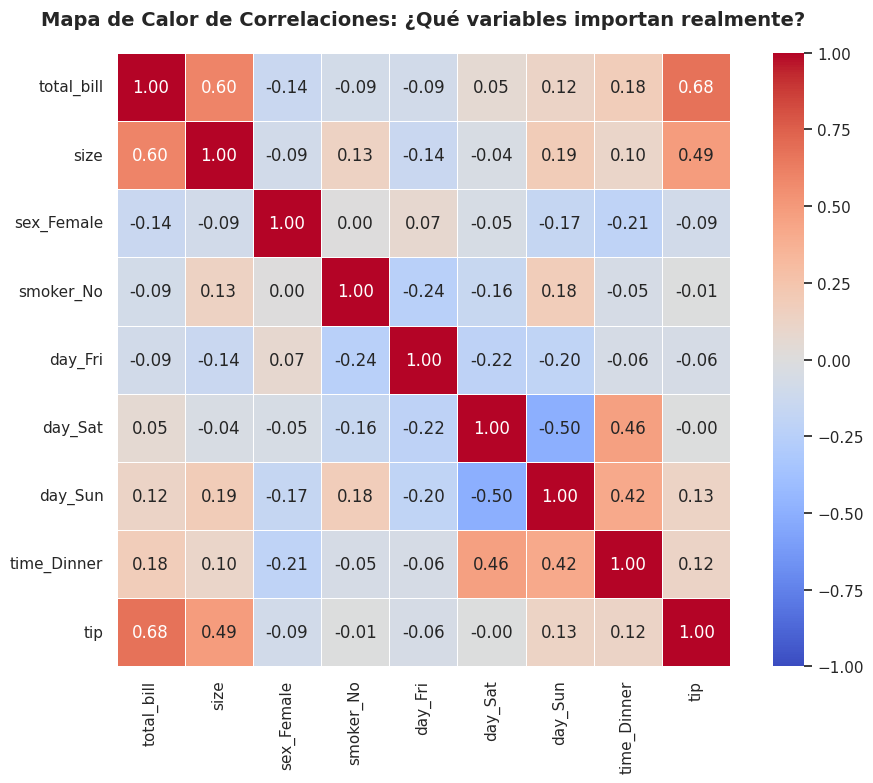

In [ ]:
# =====================================================================
# EL FILTRO PREVIO: Mapa de Calor de Correlaciones
# =====================================================================
# Unimos temporalmente X (predictores numéricos y dummies) y la Y (tip)
# en un solo DataFrame para poder ver todas las interacciones juntas.
df_analisis = X.copy()
df_analisis['tip'] = y

# Calculamos la matriz de correlación de Pearson
matriz_corr = df_analisis.corr()

# Configuramos el lienzo para que se vea espectacular
plt.figure(figsize=(10, 8))

# Dibujamos el Heatmap usando Seaborn
sns.heatmap(matriz_corr,
            annot=True,          # Muestra los números exactos
            fmt=".2f",           # Formato a 2 decimales
            cmap='coolwarm',     # Paleta: Rojo para positivo, Azul para negativo
            vmin=-1, vmax=1,     # Escala estricta de correlación
            linewidths=0.5,      # Líneas blancas separando las celdas
            square=True)         # Celdas perfectamente cuadradas

plt.title("Mapa de Calor de Correlaciones: ¿Qué variables importan realmente?",
          fontweight='bold', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

### La Cura contra el Sobreajuste: Selección de Características (Feature Selection)

El Mapa de Calor nos dio un diagnóstico claro: al cliente no le importa el día de la semana ni el género a la hora de dar propina; solo le importa el tamaño de la cuenta (`total_bill`) y el número de comensales (`size`).

Vamos a entrenar un **Modelo 3 (Optimizado)**. Haremos una "poda" de nuestra base de datos, eliminando las 6 columnas basura y conservando únicamente nuestras 2 variables estrella.

**Nuestra Hipótesis:**
Al quitarle el "ruido" al algoritmo, este dejará de intentar memorizar patrones falsos (evitando el sobreajuste) y se concentrará al 100% en la señal real del negocio. Esperamos que este modelo simple sea igual de preciso (o mejor) que el Modelo Base, pero utilizando solo una fracción del esfuerzo computacional.

--- ENTRENANDO EL MODELO 3 (OPTIMIZADO) ---
Variables utilizadas: ['total_bill', 'size']

EL TORNEO FINAL DE MACHINE LEARNING (EVALUACIÓN EN TEST)
MODELO 1 (Regresión Base - 8 Variables):
   -> MAE: $0.70 | MSE: 0.86 | R2: 0.350

MODELO 2 (Interacciones Polinómicas - Decenas de Variables):
   -> MAE: $0.75 | MSE: 0.93 | R2: 0.302 <-- (El Fracaso por Sobreajuste)

MODELO 3 (Regresión Optimizada - SOLO 2 Variables):
   -> MAE: $0.67 | MSE: 0.77 | R2: 0.418 <-- (La Elegancia)



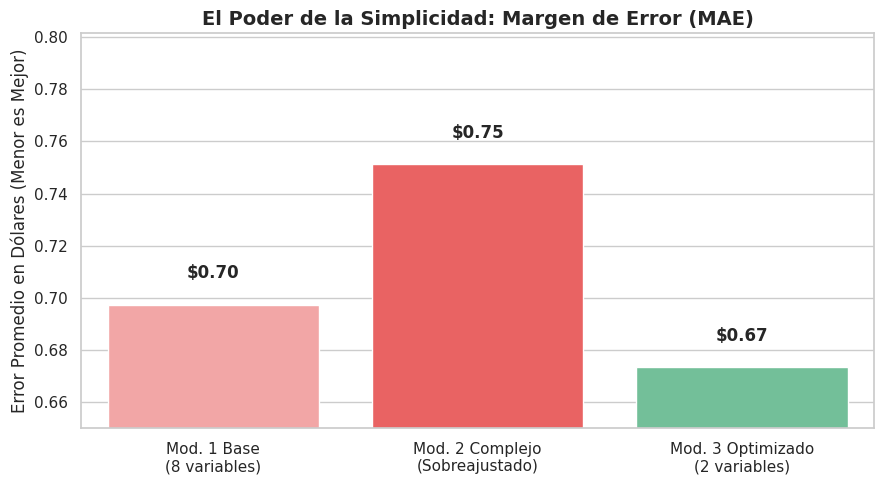

In [ ]:
# =====================================================================
# 1. La Poda de Variables (Feature Selection)
# =====================================================================
print("--- ENTRENANDO EL MODELO 3 (OPTIMIZADO) ---")

# Filtramos nuestras bóvedas de datos para quedarnos SOLO con las variables ganadoras
columnas_ganadoras = ['total_bill', 'size']

X_train_opt = X_train[columnas_ganadoras]
X_test_opt = X_test[columnas_ganadoras]

print(f"Variables utilizadas: {columnas_ganadoras}")

# =====================================================================
# 2. Entrenamiento y Predicción
# =====================================================================
modelo_optimizado = LinearRegression()
modelo_optimizado.fit(X_train_opt, y_train)

# Predicción en el futuro (Test)
pred_opt_test = modelo_optimizado.predict(X_test_opt)

# Calculamos las métricas del nuevo modelo
mae_opt = mean_absolute_error(y_test, pred_opt_test)
mse_opt = mean_squared_error(y_test, pred_opt_test)
r2_opt = r2_score(y_test, pred_opt_test)

# =====================================================================
# 3. El Gran Reporte Final Comparativo
# =====================================================================
print("\n==============================================================================")
print("EL TORNEO FINAL DE MACHINE LEARNING (EVALUACIÓN EN TEST)")
print("==============================================================================")
print("MODELO 1 (Regresión Base - 8 Variables):")
print(f"   -> MAE: ${mae_base:.2f} | MSE: {mse_base:.2f} | R2: {r2_base:.3f}")

print("\nMODELO 2 (Interacciones Polinómicas - Decenas de Variables):")
print(f"   -> MAE: ${mae_avanzado:.2f} | MSE: {mse_avanzado:.2f} | R2: {r2_avanzado:.3f} <-- (El Fracaso por Sobreajuste)")

print("\nMODELO 3 (Regresión Optimizada - SOLO 2 Variables):")
print(f"   -> MAE: ${mae_opt:.2f} | MSE: {mse_opt:.2f} | R2: {r2_opt:.3f} <-- (La Elegancia)")
print("==============================================================================\n")

# =====================================================================
# 4. Visualización del Torneo
# =====================================================================
nombres_modelos = ['Mod. 1 Base\n(8 variables)', 'Mod. 2 Complejo\n(Sobreajustado)', 'Mod. 3 Optimizado\n(2 variables)']
maes_finales = [mae_base, mae_avanzado, mae_opt]

plt.figure(figsize=(9, 5))
# Usamos hue=nombres_modelos
barras = sns.barplot(x=nombres_modelos, y=maes_finales, hue=nombres_modelos,
                     palette=['#ff9999', '#ff4d4d', '#66cc99'], legend=False)

# Anotaciones numéricas
for i, valor in enumerate(maes_finales):
    plt.text(i, valor + 0.01, f"${valor:.2f}", ha='center', fontweight='bold', fontsize=12)

plt.title("El Poder de la Simplicidad: Margen de Error (MAE)", fontweight='bold', fontsize=14)
plt.ylabel("Error Promedio en Dólares (Menor es Mejor)", fontsize=12)
plt.xlabel("")
plt.ylim(0.65, max(maes_finales) + 0.05) # Ajustamos el eje Y para ver mejor la diferencia
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error, r2_score

# =====================================================================
# 1. Carga y División de Datos
# =====================================================================
df_tips = sns.load_dataset('tips')
X = pd.get_dummies(df_tips.drop(columns=['tip']), drop_first=True)
y = df_tips['tip']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# =====================================================================
# 2. El Paso Crítico: ESTANDARIZACIÓN (Curando la ceguera de la IA)
# =====================================================================
print("--- ESCALANDO LOS DATOS ---")
scaler = StandardScaler()

# Ajustamos el escalador SOLO con los datos de entrenamiento para no hacer trampa
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =====================================================================
# 3. Entrenando el Modelo LASSO (alpha es la fuerza del látigo)
# =====================================================================
print("--- ENTRENANDO MODELO LASSO ---")
# alpha=0.05 significa una penalización moderada.
# Si alpha=0, es una regresión normal. Si alpha es muy alto, borra todo.
modelo_lasso = Lasso(alpha=0.05, random_state=42)
modelo_lasso.fit(X_train_scaled, y_train)

pred_lasso = modelo_lasso.predict(X_test_scaled)
mae_lasso = mean_absolute_error(y_test, pred_lasso)
r2_lasso = r2_score(y_test, pred_lasso)

# =====================================================================
# 4. El Veredicto Final: ¿Qué variables sobrevivieron a LASSO?
# =====================================================================
print("\n==============================================================================")
print("AUDITORÍA DEL MODELO LASSO")
print("==============================================================================")
print(f"   -> Error Absoluto (MAE)  : ${mae_lasso:.4f}")
print(f"   -> Poder Predictivo (R2) :  {r2_lasso:.4f}\n")

print("--- COEFICIENTES (¿A quién eliminó el algoritmo?) ---")
for var, coef in zip(X.columns, modelo_lasso.coef_):
    if coef == 0.0:
        print(f"❌ {var.ljust(15)}: {coef:>7.4f} (ELIMINADA POR LASSO)")
    else:
        print(f"✅ {var.ljust(15)}: {coef:>7.4f} (SOBREVIVIENTE)")
print("==============================================================================\n")

--- ESCALANDO LOS DATOS ---
--- ENTRENANDO MODELO LASSO ---

AUDITORÍA DEL MODELO LASSO
   -> Error Absoluto (MAE)  : $0.6774
   -> Poder Predictivo (R2) :  0.4089

--- COEFICIENTES (¿A quién eliminó el algoritmo?) ---
✅ total_bill     :  0.8267 (SOBREVIVIENTE)
✅ size           :  0.1763 (SOBREVIVIENTE)
❌ sex_Female     : -0.0000 (ELIMINADA POR LASSO)
✅ smoker_No      :  0.0734 (SOBREVIVIENTE)
❌ day_Fri        :  0.0000 (ELIMINADA POR LASSO)
❌ day_Sat        : -0.0000 (ELIMINADA POR LASSO)
❌ day_Sun        :  0.0000 (ELIMINADA POR LASSO)
❌ time_Dinner    : -0.0000 (ELIMINADA POR LASSO)



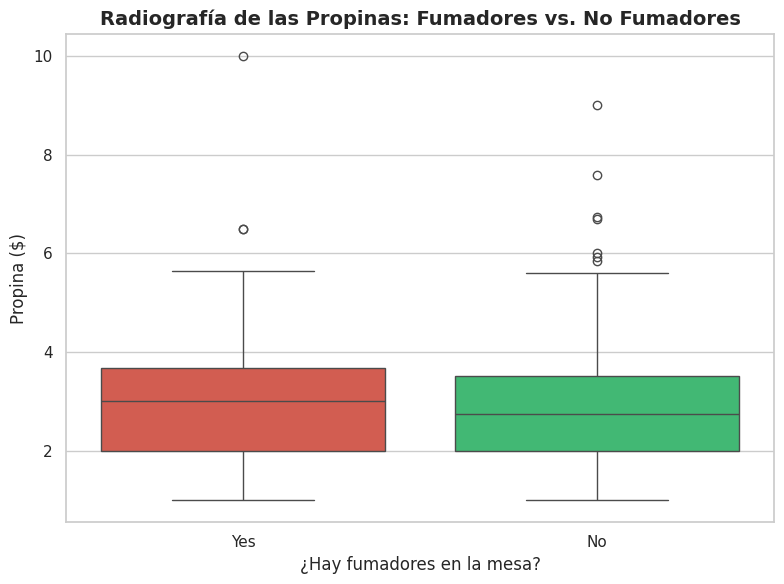

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# =====================================================================
# 1. Carga de Datos y Configuración Visual
# =====================================================================
df_tips = sns.load_dataset('tips')
sns.set_theme(style="whitegrid")

# =====================================================================
# 2. Creando el Boxplot: Fumadores vs No Fumadores
# =====================================================================
plt.figure(figsize=(8, 6))

# Usamos colores contrastantes: Rojo para Fumadores, Verde para No Fumadores
sns.boxplot(data=df_tips, x='smoker', y='tip', hue='smoker',
            palette={'Yes': '#e74c3c', 'No': '#2ecc71'}, legend=False)

# Títulos y etiquetas claras
plt.title("Radiografía de las Propinas: Fumadores vs. No Fumadores", fontweight='bold', fontsize=14)
plt.xlabel("¿Hay fumadores en la mesa?", fontsize=12)
plt.ylabel("Propina ($)", fontsize=12)

plt.tight_layout()
plt.show()